In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/archive (1).zip")
df.sample(5)

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,in_balanced_dataset
13356,Business Analyst (Consultant- Director level),"GB, LND,",NaN,NaN,<p>Founded by serial entrepreneur Clive Jackso...,<p>We are looking for truly exceptional talent...,<ul>\r\n<li>Expert understanding of business m...,NaN,f,t,f,Contract,NaN,NaN,Airlines/Aviation,Business Analyst,f,f
6494,Digital Marketing & Web Producer,"US, MA, Boston",Marketing,NaN,"<p>Spartan Race, is an international obstacle ...",<p>This role is responsible for the developmen...,<p>SKILLS/EXPERIENCE:</p>\r\n<ul>\r\n<li>Bache...,<p>Spartan Race offers a competitive salary an...,f,t,t,Full-time,Mid-Senior level,Bachelor's Degree,Sports,Marketing,f,f
11055,English Teacher Abroad,"US, FL, Hollywood",NaN,NaN,<p>We help teachers get safe &amp; secure jobs...,"<p>Play with kids, get paid for it </p>\r\n<p>...",<p>University degree required. TEFL / TESOL / ...,<p>See job description</p>,f,t,t,Contract,NaN,Bachelor's Degree,Education Management,NaN,f,f
1535,Jr. Account Executive,"US, CA, San Diego",SALES,NaN,NaN,<p>Responsible to generate new business and Ma...,<p>Must have at least 1 year of experience in ...,NaN,f,f,t,NaN,NaN,NaN,NaN,NaN,f,f
17779,J2EE Developer Required for Bahrain,"BH, 13,",Information Technology,NaN,NaN,<p><b>Greetings from VAM SYSTEMS…..</b></p>\r\...,<p><b>Skillset required</b>:</p>\r\n<ul>\r\n<l...,NaN,f,f,t,NaN,NaN,NaN,NaN,NaN,t,t


In [8]:
print("Shape of data :",df.shape)
df.info()
print("Missing values in data :",df.isna().sum())
print("Duplicate values in data :",df.duplicated().sum())

Shape of data : (17880, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                17880 non-null  object
 1   location             17534 non-null  object
 2   department           6333 non-null   object
 3   salary_range         2868 non-null   object
 4   company_profile      14572 non-null  object
 5   description          17880 non-null  object
 6   requirements         15191 non-null  object
 7   benefits             10684 non-null  object
 8   telecommuting        17880 non-null  object
 9   has_company_logo     17880 non-null  object
 10  has_questions        17880 non-null  object
 11  employment_type      14409 non-null  object
 12  required_experience  10830 non-null  object
 13  required_education   9775 non-null   object
 14  industry             12977 non-null  object
 15  function             1142

<h3>Cleaning Data


In [10]:
df_raw = df.copy()

# Remove the dataset-selection flag
df_clean = df_raw.drop(columns=["in_balanced_dataset"]).copy()

# Remove duplicates
before = len(df_clean)

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Rows before:", before)
print("Duplicates removed:", before - len(df_clean))
print("Rows remaining:", len(df_clean))

Rows before: 17880
Duplicates removed: 248
Rows remaining: 17632


In [11]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

df_model = df_clean[text_columns + ["fraudulent"]].copy()

print("Model dataset shape:", df_model.shape)

Model dataset shape: (17632, 6)


In [12]:
df_model[text_columns] = df_model[text_columns].fillna("")

print("Missing values after filling:")
print(df_model.isna().sum())

Missing values after filling:
title              0
company_profile    0
description        0
requirements       0
benefits           0
fraudulent         0
dtype: int64


In [13]:
labels = df_model["fraudulent"].str.strip().str.lower()

# Check before converting
assert labels.isin(["t", "f"]).all(), "Unexpected target values found"

df_model["fraudulent"] = labels.map({
    "f": 0,  # Labelled legitimate
    "t": 1   # Labelled fraudulent
})

print("Class counts:")
print(df_model["fraudulent"].value_counts().sort_index())

print("\nClass percentages:")
print(df_model["fraudulent"].value_counts(normalize=True).sort_index().mul(100).round(2))

Class counts:
fraudulent
0    16776
1      856
Name: count, dtype: int64

Class percentages:
fraudulent
0    95.15
1     4.85
Name: proportion, dtype: float64


In [14]:
%pip install -q beautifulsoup4

In [15]:
import pandas as pd
import re
from html import unescape
from bs4 import BeautifulSoup

def clean_job_text(value):
    # Missing text becomes an empty string
    if pd.isna(value):
        return ""

    text = str(value)

    # Replace literal escaped whitespace found in this dataset
    for escaped in (r"\r", r"\n", r"\t"):
        text = text.replace(escaped, " ")

    soup = BeautifulSoup(text, "html.parser")

    # Remove code and styling content
    for tag in soup(["script", "style"]):
        tag.decompose()

    # Preserve links that would otherwise disappear with HTML tags
    for link in soup.find_all("a", href=True):
        target = link["href"].strip()

        if target.lower().startswith(("http://", "https://", "mailto:")):
            if target not in link.get_text():
                link.append(" " + target)

    # Extract text and decode entities such as &amp;
    text = unescape(soup.get_text(separator=" "))

    # Remove invisible formatting characters
    text = text.replace("\u200b", "").replace("\ufeff", "")

    # Normalize whitespace and case
    return re.sub(r"\s+", " ", text).strip().lower()

In [16]:
df_text = df_clean.copy()

text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

clean_columns = []

for column in text_columns:
    clean_column = f"{column}_clean"

    df_text[clean_column] = df_text[column].apply(clean_job_text)
    clean_columns.append(clean_column)

# Combine cleaned fields into one candidate input for TF-IDF
df_text["text"] = (
    df_text[clean_columns]
    .agg(" ".join, axis=1)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [17]:
binary_columns = [
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "fraudulent"
]

binary_mapping = {
    "t": 1, "f": 0,
    "true": 1, "false": 0,
    "1": 1, "0": 0
}

for column in binary_columns:
    values = df_text[column].astype("string").str.strip().str.lower()

    unexpected = values[
        values.notna() & ~values.isin(binary_mapping)
    ].unique().tolist()

    if unexpected:
        raise ValueError(f"Unexpected values in {column}: {unexpected}")

    df_text[column] = values.map(binary_mapping).astype("Int64")

In [18]:
print("Rows:", len(df_text))
print("Empty combined texts:", df_text["text"].eq("").sum())

print("\nClass counts:")
print(df_text["fraudulent"].value_counts().sort_index())

print("\nBEFORE:")
print(df_text.iloc[0]["description"])

print("\nAFTER:")
print(df_text.iloc[0]["description_clean"])

display(df_text[["title_clean", "text", "fraudulent"]].head(3))

Rows: 17632
Empty combined texts: 0

Class counts:
fraudulent
0    16776
1      856
Name: count, dtype: Int64

BEFORE:
<p>Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and curated recipe hub, is currently interviewing full- and part-time unpaid interns to work in a small team of editors, executives, and developers in its New York City headquarters.</p>
<ul>
<li>Reproducing and/or repackaging existing Food52 content for a number of partner sites, such as Huffington Post, Yahoo, Buzzfeed, and more in their various content management systems</li>
<li>Researching blogs and websites for the Provisions by Food52 Affiliate Program</li>
<li>Assisting in day-to-day affiliate program support, such as screening affiliates and assisting in any affiliate inquiries</li>
<li>Supporting with PR &amp; Events when needed</li>
<li>Helping with office administrative work, such as filing, mailing, and preparing for meetings</li>
<li>Working with developers to doc

,title_clean,text,fraudulent
0,marketing intern,"marketing intern we're food52, and we've creat...",0
1,customer service - cloud video production,customer service - cloud video production 90 s...,0
2,commissioning machinery assistant (cma),commissioning machinery assistant (cma) valor ...,0


In [19]:
# Group records with exactly the same cleaned combined text
text_audit = (
    df_text.groupby("text", sort=False)
    .agg(
        row_count=("fraudulent", "size"),
        unique_labels=("fraudulent", "nunique")
    )
)

# Find texts assigned both labels: 0 and 1
conflicting_texts = text_audit.index[text_audit["unique_labels"] > 1]

df_conflicts = df_text[
    df_text["text"].isin(conflicting_texts)
].copy()

print("Extra rows with repeated text:",df_text.duplicated(subset=["text"]).sum())

print("Distinct texts with conflicting labels:",len(conflicting_texts))

print("Rows involved in conflicts:",len(df_conflicts))

if not df_conflicts.empty:
    display(
        df_conflicts[
            ["title_clean", "location", "fraudulent", "text"]
        ].head(10)
    )

Extra rows with repeated text: 1825
Distinct texts with conflicting labels: 0
Rows involved in conflicts: 0


In [20]:
df_ready = (
    df_text
    .drop_duplicates(subset=["text"], keep="first")
    .reset_index(drop=True)
    .copy()
)

print("Rows before:", len(df_text))
print("Repeated-text rows removed:", len(df_text) - len(df_ready))
print("Rows remaining:", len(df_ready))

print("\nUpdated class counts:")
print(df_ready["fraudulent"].value_counts().sort_index())

print("\nUpdated class percentages:")
print(
    df_ready["fraudulent"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Rows before: 17632
Repeated-text rows removed: 1825
Rows remaining: 15807

Updated class counts:
fraudulent
0    15095
1      712
Name: count, dtype: Int64

Updated class percentages:
fraudulent
0    95.5
1     4.5
Name: proportion, dtype: Float64


<h2>Splitting the dataset

In [21]:
from sklearn.model_selection import train_test_split

# Reserve 30% for validation and testing
train_df, temporary_df = train_test_split(
    df_ready,
    test_size=0.30,
    stratify=df_ready["fraudulent"],
    random_state=42
)

# Divide that 30% approximately equally
val_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    stratify=temporary_df["fraudulent"],
    random_state=42
)

# Give each dataframe a fresh index
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [23]:
split_summary = pd.DataFrame([
    {
        "Split": name,
        "Rows": len(part),
        "Legitimate": int(part["fraudulent"].eq(0).sum()),
        "Fraudulent": int(part["fraudulent"].eq(1).sum()),
        "Fraud %": round(part["fraudulent"].mean() * 100, 2)
    }
    for name, part in [
        ("Train", train_df),
        ("Validation", val_df),
        ("Test", test_df)
    ]
])

print(split_summary)

        Split   Rows  Legitimate  Fraudulent  Fraud %
0       Train  11064       10566         498     4.50
1  Validation   2371        2264         107     4.51
2        Test   2372        2265         107     4.51


<h3> EDA

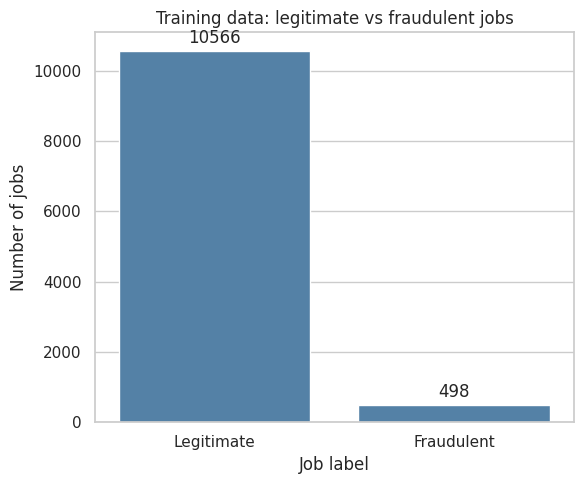

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Work on a separate copy for exploration
eda = train_df.copy()

eda["label"] = eda["fraudulent"].map({
    0: "Legitimate",
    1: "Fraudulent"
})

class_order = ["Legitimate", "Fraudulent"]

plt.figure(figsize=(6, 5))

ax = sns.countplot(
    data=eda,
    x="label",
    order=class_order,
    color="steelblue"
)

ax.bar_label(ax.containers[0], padding=3)
ax.set(
    title="Training data: legitimate vs fraudulent jobs",
    xlabel="Job label",
    ylabel="Number of jobs"
)

plt.tight_layout()
plt.show()

,Column,Missing %
0,salary_range,83.05
1,department,61.45
2,required_education,45.98
3,benefits,41.12
4,required_experience,36.88
5,function,33.60
6,industry,28.28
7,employment_type,20.18
8,company_profile,19.53
9,requirements,13.92


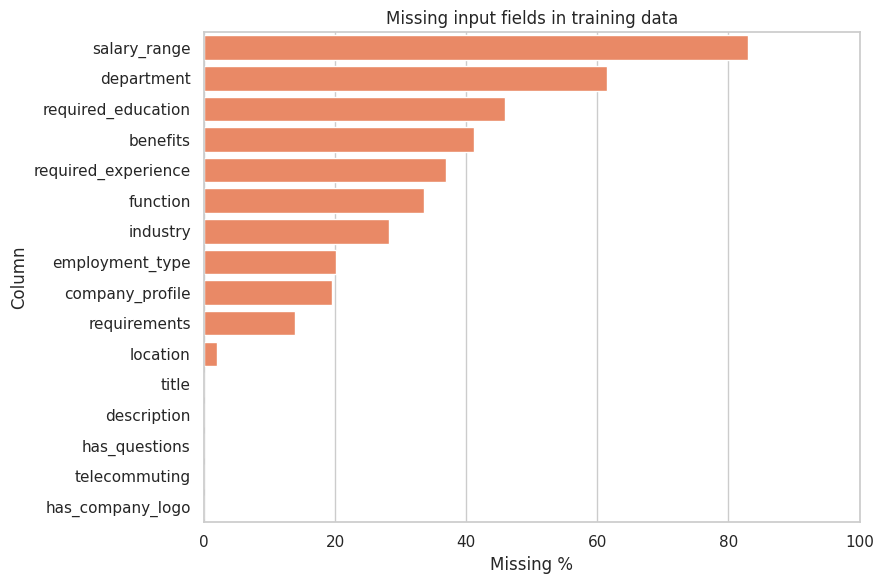

In [29]:
# Original input columns, excluding the target
original_features = df_clean.columns.drop("fraudulent").tolist()

# Count both NaN and blank strings as missing
missing_pct = (
    eda[original_features]
    .replace(r"^\s*$", pd.NA, regex=True)
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_summary = (
    missing_pct
    .rename("Missing %")
    .rename_axis("Column")
    .reset_index()
)

display(missing_summary.round(2))

plt.figure(figsize=(9, 6))

sns.barplot(
    data=missing_summary,
    x="Missing %",
    y="Column",
    color="coral"
)

plt.xlim(0, 100)
plt.title("Missing input fields in training data")
plt.tight_layout()
plt.show()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
Fraudulent,498.0,328.1,239.2,5.0,136.5,269.5,466.5,1421.0
Legitimate,10566.0,418.2,211.8,12.0,268.0,389.0,529.0,2118.0


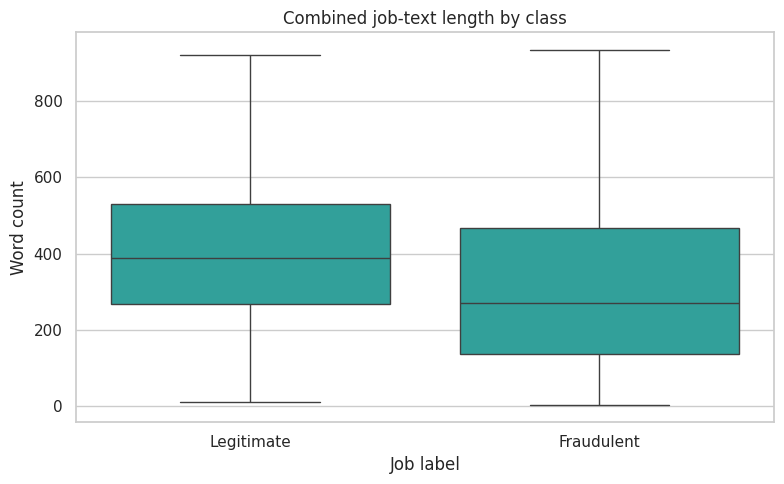

In [30]:
# Approximate word count: count sequences of non-whitespace characters
eda["word_count"] = eda["text"].str.count(r"\S+")

display(
    eda.groupby("label")["word_count"]
    .describe()
    .round(1)
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda,
    x="label",
    y="word_count",
    order=class_order,
    color="lightseagreen",
    showfliers=False
)

plt.title("Combined job-text length by class")
plt.xlabel("Job label")
plt.ylabel("Word count")
plt.tight_layout()
plt.show()

In [31]:
missing_cols = [
    "salary_range",
    "department",
    "required_education",
    "benefits",
    "required_experience",
    "function",
    "industry",
    "employment_type",
    "company_profile",
    "requirements",
    "location"
]

missing_by_class = (
    train_df
    .groupby("fraudulent")[missing_cols]
    .agg(lambda x: x.isna().mean() * 100)
    .T
)

missing_by_class.columns = [
    "Legitimate Missing %",
    "Fraudulent Missing %"
]

missing_by_class["Difference"] = (
    missing_by_class["Fraudulent Missing %"]
    - missing_by_class["Legitimate Missing %"]
)

missing_by_class = missing_by_class.sort_values(
    "Difference",
    ascending=False
)

missing_by_class.round(2)

,Legitimate Missing %,Fraudulent Missing %,Difference
company_profile,17.38,65.26,47.88
required_experience,36.35,47.99,11.64
benefits,40.87,46.39,5.52
employment_type,20.03,23.49,3.47
required_education,45.83,49.20,3.37
requirements,13.77,17.07,3.30
industry,28.19,30.12,1.93
function,33.52,35.14,1.62
location,1.98,2.21,0.23
department,61.52,58.84,-2.68


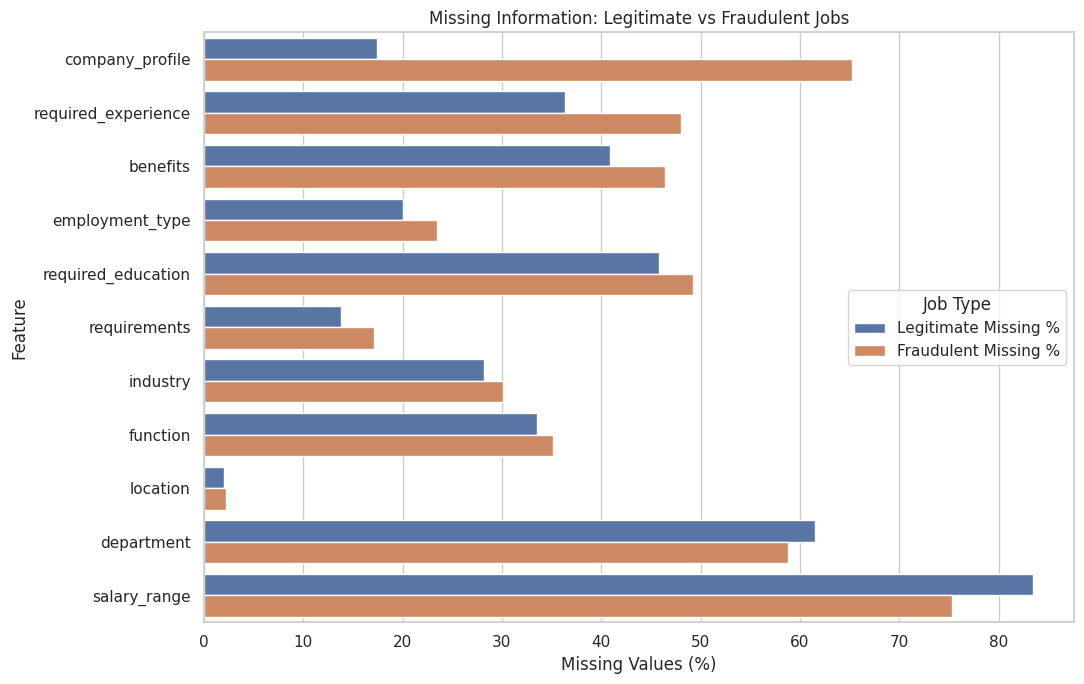

In [32]:
plot_df = (
    missing_by_class[
        ["Legitimate Missing %", "Fraudulent Missing %"]
    ]
    .reset_index()
    .melt(
        id_vars="index",
        var_name="Job Type",
        value_name="Missing %"
    )
)

plot_df = plot_df.rename(columns={"index": "Feature"})

plt.figure(figsize=(11, 7))

sns.barplot(
    data=plot_df,
    y="Feature",
    x="Missing %",
    hue="Job Type"
)

plt.title("Missing Information: Legitimate vs Fraudulent Jobs")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

<h3>EDA on binary features

In [33]:
binary_cols = [
    "has_company_logo",
    "has_questions",
    "telecommuting"
]

for col in binary_cols:
    print(f"\n{'='*45}")
    print(f"Feature: {col}")
    print("="*45)

    result = (
        train_df
        .groupby(col)["fraudulent"]
        .agg(["count", "sum", "mean"])
    )

    result["fraud_rate_%"] = result["mean"] * 100

    print(result[["count", "sum", "fraud_rate_%"]].round(2))


Feature: has_company_logo
                  count  sum  fraud_rate_%
has_company_logo                          
0                  2198  320         14.56
1                  8866  178          2.01

Feature: has_questions
               count  sum  fraud_rate_%
has_questions                          
0               5624  340          6.05
1               5440  158           2.9

Feature: telecommuting
               count  sum  fraud_rate_%
telecommuting                          
0              10606  458          4.32
1                458   40          8.73


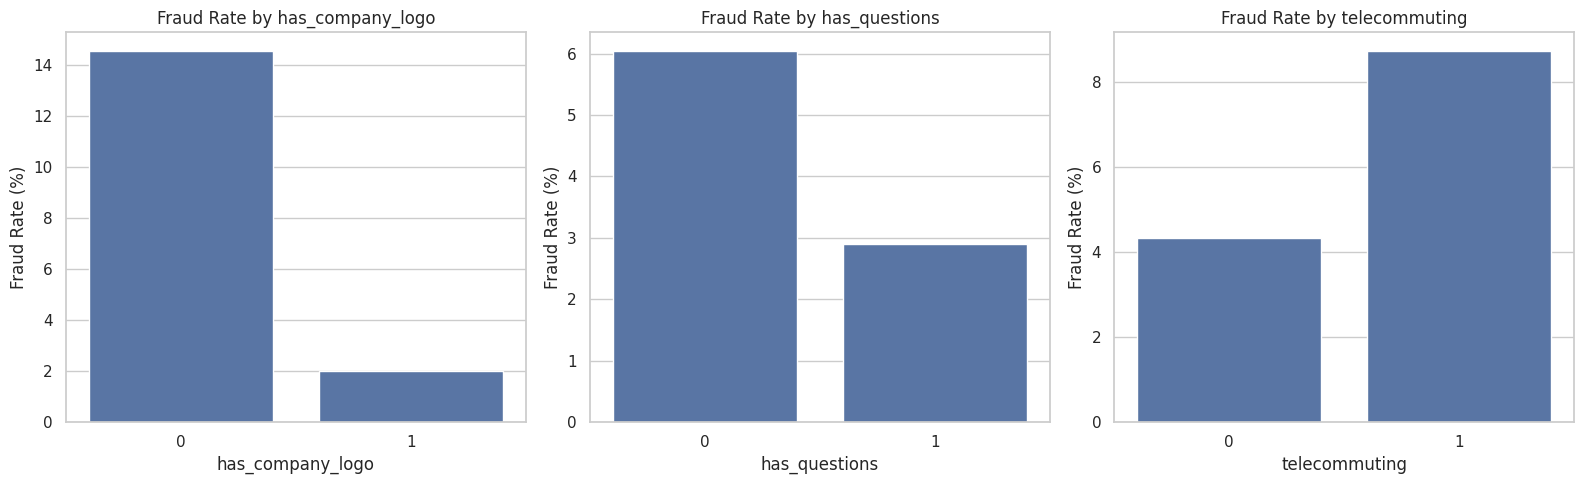

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, binary_cols):

    fraud_rate = (
        train_df
        .groupby(col)["fraudulent"]
        .mean()
        .mul(100)
        .reset_index()
    )

    sns.barplot(
        data=fraud_rate,
        x=col,
        y="fraudulent",
        ax=ax
    )

    ax.set_title(f"Fraud Rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

<h3>EDA on categorical feature

In [35]:
categorical_cols = [
    "employment_type",
    "required_experience",
    "required_education",
    "function",
    "industry"
]

categorical_summary = []

for col in categorical_cols:
    categorical_summary.append({
        "feature": col,
        "unique_categories": train_df[col].nunique(dropna=True),
        "missing_%": train_df[col].isna().mean() * 100
    })

categorical_summary = pd.DataFrame(categorical_summary)

categorical_summary.round(2)

,feature,unique_categories,missing_%
0,employment_type,5,20.18
1,required_experience,7,36.88
2,required_education,13,45.98
3,function,37,33.60
4,industry,128,28.28


In [36]:
employment_analysis = (
    train_df
    .groupby("employment_type", dropna=False)["fraudulent"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

employment_analysis["fraud_rate_%"] = (
    employment_analysis["mean"] * 100
)

employment_analysis = employment_analysis.sort_values(
    "fraud_rate_%",
    ascending=False
)

employment_analysis[
    ["employment_type", "count", "sum", "fraud_rate_%"]
].round(2)

,employment_type,count,sum,fraud_rate_%
3,Part-time,537,51,9.5
5,NaN,2233,117,5.24
1,Full-time,7436,304,4.09
2,Other,145,5,3.45
0,Contract,556,19,3.42
4,Temporary,157,2,1.27


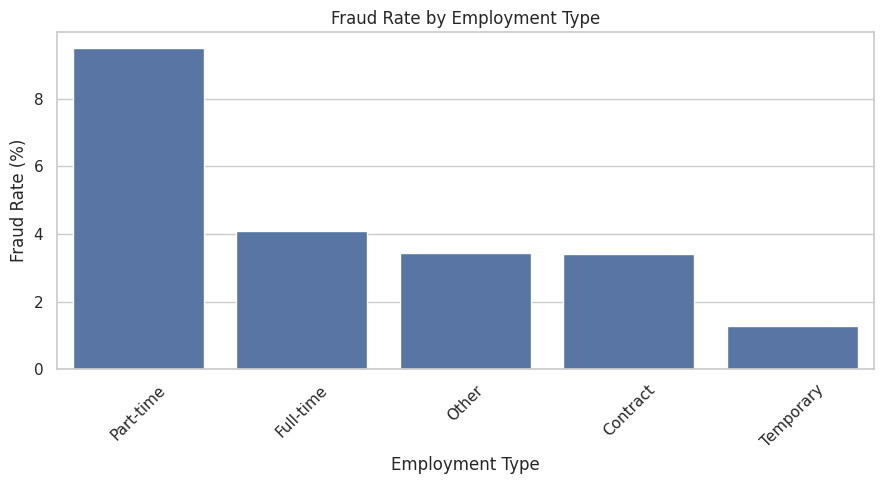

In [37]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=employment_analysis,
    x="employment_type",
    y="fraud_rate_%"
)

plt.title("Fraud Rate by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Plotting missing category also....

In [38]:
employment_plot = train_df.copy()

employment_plot["employment_type"] = (
    employment_plot["employment_type"]
    .fillna("Missing")
)

employment_analysis = (
    employment_plot
    .groupby("employment_type")["fraudulent"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

employment_analysis["fraud_rate_%"] = (
    employment_analysis["mean"] * 100
)

employment_analysis = employment_analysis.sort_values(
    "fraud_rate_%",
    ascending=False
)

employment_analysis[
    ["employment_type", "count", "sum", "fraud_rate_%"]
].round(2)

,employment_type,count,sum,fraud_rate_%
4,Part-time,537,51,9.5
2,Missing,2233,117,5.24
1,Full-time,7436,304,4.09
3,Other,145,5,3.45
0,Contract,556,19,3.42
5,Temporary,157,2,1.27


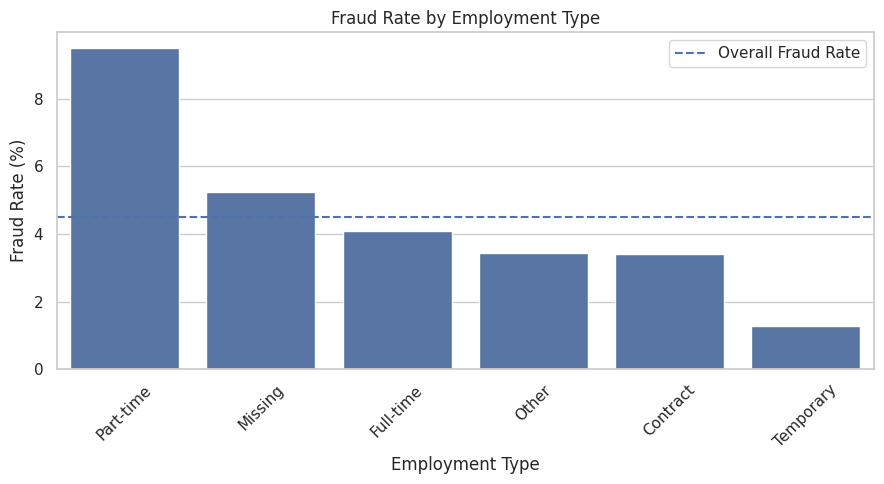

In [39]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=employment_analysis,
    x="employment_type",
    y="fraud_rate_%"
)

plt.axhline(
    train_df["fraudulent"].mean() * 100,
    linestyle="--",
    label="Overall Fraud Rate"
)

plt.title("Fraud Rate by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [40]:
def categorical_fraud_analysis(df, column):

    temp = df[[column, "fraudulent"]].copy()

    # Keep missingness as its own category
    temp[column] = temp[column].fillna("Missing")

    result = (
        temp
        .groupby(column)["fraudulent"]
        .agg(["count", "sum", "mean"])
        .reset_index()
    )

    result["fraud_rate_%"] = result["mean"] * 100

    return result.sort_values(
        "fraud_rate_%",
        ascending=False
    )

In [41]:
experience_analysis = categorical_fraud_analysis(
    train_df,
    "required_experience"
)

experience_analysis.round(2)

,required_experience,count,sum,mean,fraud_rate_%
2,Entry level,1600,108,0.07,6.75
3,Executive,91,6,0.07,6.59
6,Missing,4080,239,0.06,5.86
1,Director,251,14,0.06,5.58
7,Not Applicable,705,32,0.05,4.54
5,Mid-Senior level,2557,74,0.03,2.89
4,Internship,251,4,0.02,1.59
0,Associate,1529,21,0.01,1.37


In [42]:
education_analysis = categorical_fraud_analysis(
    train_df,
    "required_education"
)

education_analysis.round(2)

,required_education,count,sum,mean,fraud_rate_%
9,Some High School Coursework,21,16,0.76,76.19
2,Certification,105,10,0.1,9.52
5,Master's Degree,295,24,0.08,8.14
7,Professional,52,4,0.08,7.69
4,High School or equivalent,1261,92,0.07,7.3
6,Missing,5087,245,0.05,4.82
8,Some College Coursework Completed,77,3,0.04,3.9
10,Unspecified,902,34,0.04,3.77
0,Associate Degree,165,4,0.02,2.42
1,Bachelor's Degree,3045,66,0.02,2.17


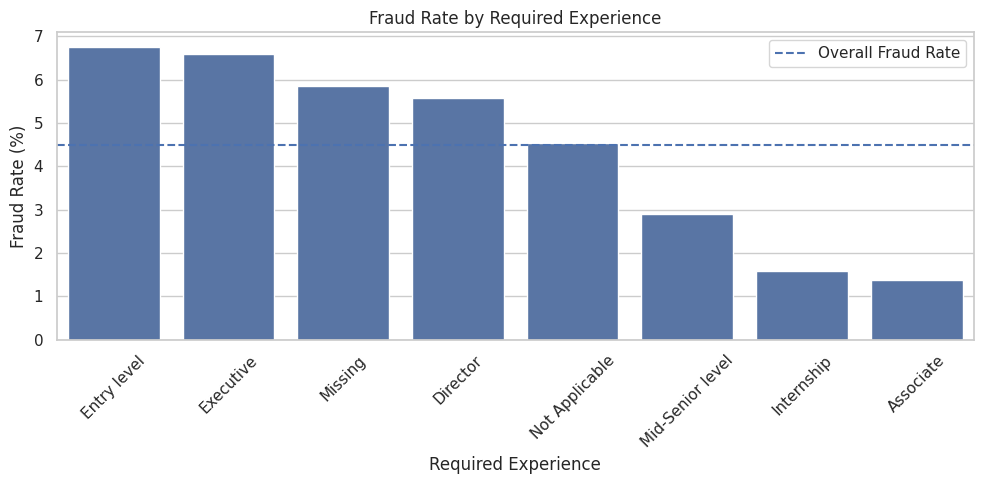

In [43]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=experience_analysis,
    x="required_experience",
    y="fraud_rate_%"
)

plt.axhline(
    train_df["fraudulent"].mean() * 100,
    linestyle="--",
    label="Overall Fraud Rate"
)

plt.title("Fraud Rate by Required Experience")
plt.xlabel("Required Experience")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

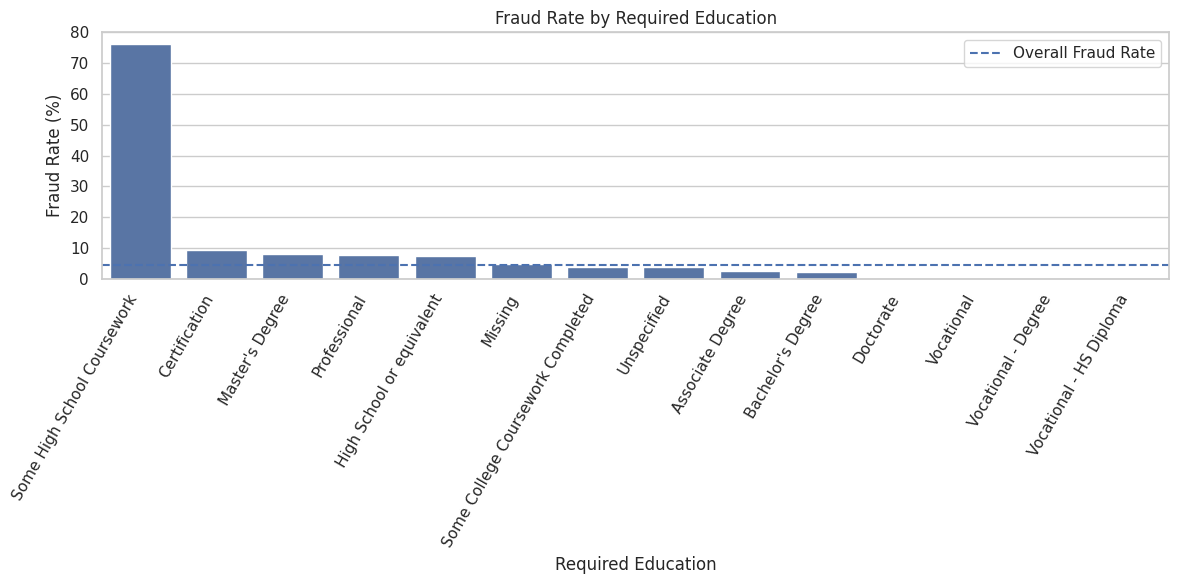

In [44]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=education_analysis,
    x="required_education",
    y="fraud_rate_%"
)

plt.axhline(
    train_df["fraudulent"].mean() * 100,
    linestyle="--",
    label="Overall Fraud Rate"
)

plt.title("Fraud Rate by Required Education")
plt.xlabel("Required Education")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=60, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

<h3>EDA on 'function' and 'industry' columns

In [45]:
def high_cardinality_analysis(df, column, min_count=30):

    temp = df[[column, "fraudulent"]].copy()

    temp[column] = temp[column].fillna("Missing")

    result = (
        temp
        .groupby(column)["fraudulent"]
        .agg(["count", "sum", "mean"])
        .reset_index()
    )

    result["fraud_rate_%"] = result["mean"] * 100

    # Keep categories with reasonable support
    supported = result[
        result["count"] >= min_count
    ].copy()

    supported = supported.sort_values(
        "fraud_rate_%",
        ascending=False
    )

    return result, supported

In [46]:
function_all, function_supported = high_cardinality_analysis(
    train_df,
    "function",
    min_count=50
)

function_supported.round(2)

,function,count,sum,mean,fraud_rate_%
1,Administrative,410,74,0.18,18.05
0,Accounting/Auditing,148,20,0.14,13.51
24,Other,209,20,0.1,9.57
12,Engineering,917,83,0.09,9.05
13,Finance,118,7,0.06,5.93
27,Project Management,119,7,0.06,5.88
23,Missing,3717,175,0.05,4.71
7,Customer Service,710,33,0.05,4.65
17,Human Resources,135,5,0.04,3.7
5,Business Development,144,5,0.03,3.47


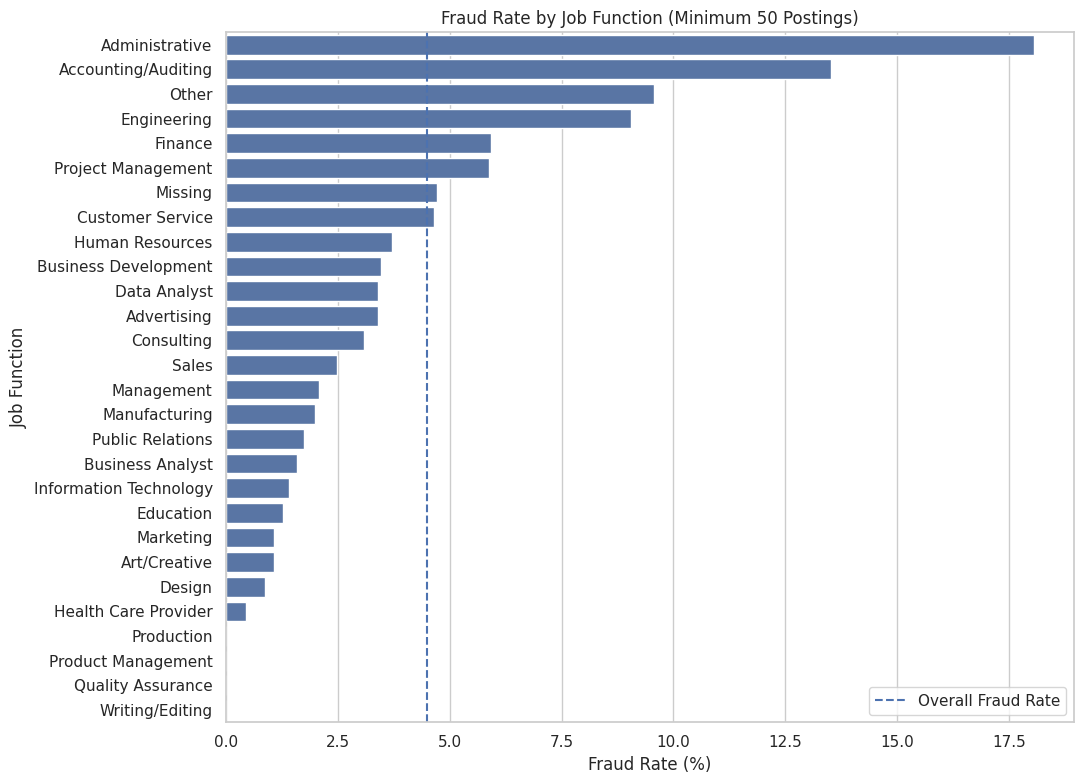

In [47]:
plt.figure(figsize=(11, 8))

sns.barplot(
    data=function_supported,
    y="function",
    x="fraud_rate_%"
)

plt.axvline(
    train_df["fraudulent"].mean() * 100,
    linestyle="--",
    label="Overall Fraud Rate"
)

plt.title("Fraud Rate by Job Function (Minimum 50 Postings)")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Job Function")

plt.legend()
plt.tight_layout()
plt.show()

In [48]:
print("Total function categories:", len(function_all))
print("Categories with >= 50 postings:", len(function_supported))
print("Categories with < 50 postings:",
      (function_all["count"] < 50).sum())

Total function categories: 38
Categories with >= 50 postings: 28
Categories with < 50 postings: 10


In [49]:
industry_all, industry_supported = high_cardinality_analysis(
    train_df,
    "industry",
    min_count=50
)

In [50]:
print("Total industry categories:", len(industry_all))

print(
    "Categories with >= 50 postings:",
    len(industry_supported)
)

print(
    "Categories with < 50 postings:",
    (industry_all["count"] < 50).sum()
)

print(
    "Postings belonging to rare industries:",
    industry_all.loc[
        industry_all["count"] < 50,
        "count"
    ].sum()
)

Total industry categories: 129
Categories with >= 50 postings: 34
Categories with < 50 postings: 95
Postings belonging to rare industries: 1373


In [51]:
industry_supported[
    ["industry", "count", "sum", "fraud_rate_%"]
].round(2)

,industry,count,sum,fraud_rate_%
88,Oil & Energy,188,80,42.55
0,Accounting,98,38,38.78
51,Hospitality,64,9,14.06
48,"Health, Wellness and Fitness",88,10,11.36
50,Hospital & Health Care,329,31,9.42
118,Telecommunications,208,16,7.69
31,Electrical/Electronic Manufacturing,53,4,7.55
52,Human Resources,57,4,7.02
107,Real Estate,100,7,7.0
25,Consumer Services,201,13,6.47


In [52]:
industry_top15 = (
    industry_supported
    .sort_values("fraud_rate_%", ascending=False)
    .head(15)
)

industry_top15[
    ["industry", "count", "sum", "fraud_rate_%"]
].round(2)

,industry,count,sum,fraud_rate_%
88,Oil & Energy,188,80,42.55
0,Accounting,98,38,38.78
51,Hospitality,64,9,14.06
48,"Health, Wellness and Fitness",88,10,11.36
50,Hospital & Health Care,329,31,9.42
118,Telecommunications,208,16,7.69
31,Electrical/Electronic Manufacturing,53,4,7.55
52,Human Resources,57,4,7.02
107,Real Estate,100,7,7.0
25,Consumer Services,201,13,6.47


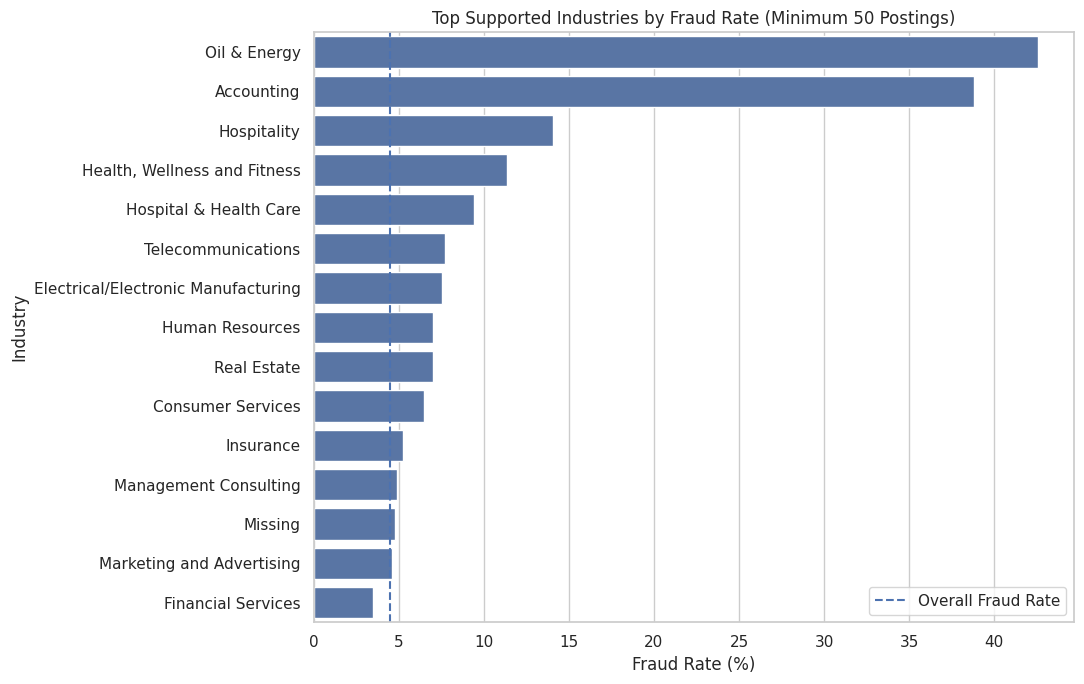

In [53]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=industry_top15,
    y="industry",
    x="fraud_rate_%"
)

plt.axvline(
    train_df["fraudulent"].mean() * 100,
    linestyle="--",
    label="Overall Fraud Rate"
)

plt.title(
    "Top Supported Industries by Fraud Rate "
    "(Minimum 50 Postings)"
)

plt.xlabel("Fraud Rate (%)")
plt.ylabel("Industry")

plt.legend()
plt.tight_layout()
plt.show()

<h2>Text-specific EDA

In [54]:
text_cols = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

text_length_df = train_df.copy()

for col in text_cols:
    text_length_df[f"{col}_word_count"] = (
        text_length_df[col]
        .fillna("")
        .astype(str)
        .str.split()
        .str.len()
    )

In [55]:
length_summary = []

for col in text_cols:
    wc_col = f"{col}_word_count"

    summary = (
        text_length_df
        .groupby("fraudulent")[wc_col]
        .agg(["mean", "median"])
    )

    length_summary.append({
        "field": col,

        "legitimate_mean":
            summary.loc[0, "mean"],

        "fraudulent_mean":
            summary.loc[1, "mean"],

        "legitimate_median":
            summary.loc[0, "median"],

        "fraudulent_median":
            summary.loc[1, "median"]
    })

length_summary = pd.DataFrame(length_summary)

length_summary.round(2)

,field,legitimate_mean,fraudulent_mean,legitimate_median,fraudulent_median
0,title,3.73,3.69,3.0,3.0
1,company_profile,103.91,38.04,86.0,0.0
2,description,194.54,188.84,165.0,130.5
3,requirements,97.59,71.02,79.0,42.0
4,benefits,36.20,30.36,11.0,3.0


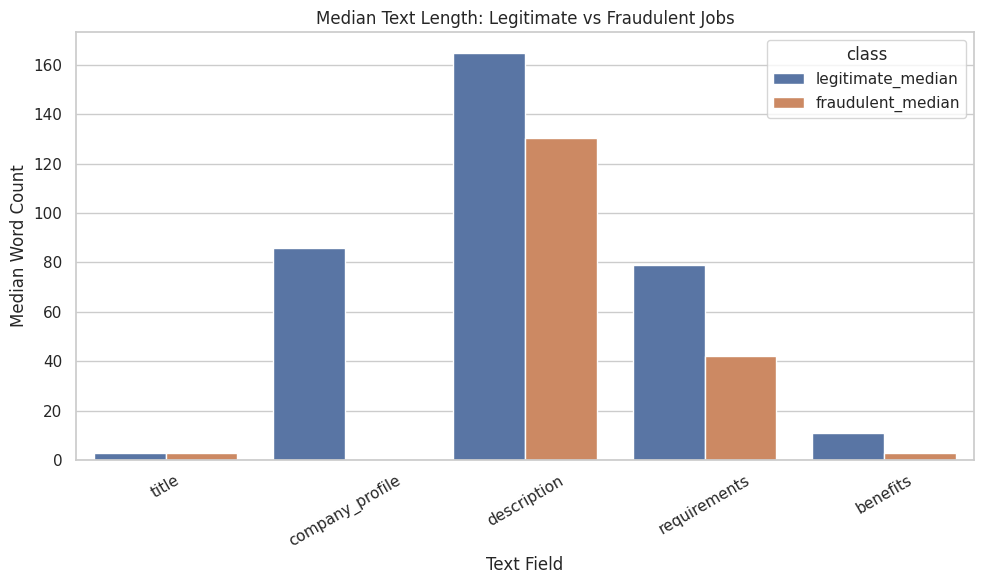

In [56]:
plot_length = length_summary.melt(
    id_vars="field",
    value_vars=[
        "legitimate_median",
        "fraudulent_median"
    ],
    var_name="class",
    value_name="median_word_count"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_length,
    x="field",
    y="median_word_count",
    hue="class"
)

plt.title("Median Text Length: Legitimate vs Fraudulent Jobs")
plt.xlabel("Text Field")
plt.ylabel("Median Word Count")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

<h3>class-normalized vocabulary EDA

In [57]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_features=10000,
    binary=True
)

X_terms = vectorizer.fit_transform(
    train_df["text"].fillna("")
)

terms = np.array(
    vectorizer.get_feature_names_out()
)

In [60]:
# Convert target column to normal NumPy array first
y_train = train_df["fraudulent"].to_numpy(dtype=int)

fraud_mask = (y_train == 1)
legit_mask = (y_train == 0)

print(type(fraud_mask))
print(fraud_mask.shape)
print(X_terms.shape)

<class 'numpy.ndarray'>
(11064,)
(11064, 10000)


In [61]:
fraud_prevalence = (
    np.asarray(
        X_terms[fraud_mask].mean(axis=0)
    )
    .ravel()
    * 100
)

legit_prevalence = (
    np.asarray(
        X_terms[legit_mask].mean(axis=0)
    )
    .ravel()
    * 100
)

In [62]:
term_analysis = pd.DataFrame({
    "term": terms,
    "fraud_doc_%": fraud_prevalence,
    "legitimate_doc_%": legit_prevalence
})

term_analysis["difference"] = (
    term_analysis["fraud_doc_%"]
    - term_analysis["legitimate_doc_%"]
)

In [63]:
fraud_terms = (
    term_analysis
    .sort_values("difference", ascending=False)
    .head(25)
)

fraud_terms.round(2)

,term,fraud_doc_%,legitimate_doc_%,difference
4,000,26.51,8.06,18.44
2916,encouraged,16.47,1.33,15.13
1976,corporate,20.88,8.04,12.85
6028,oil,14.86,2.03,12.83
8422,staffing,17.07,4.29,12.78
361,administrative,17.67,5.31,12.36
2212,data entry,13.65,1.84,11.82
9753,word,21.69,9.97,11.72
908,benefits,38.76,27.42,11.34
2755,earn,13.05,1.73,11.32


In [64]:
legit_terms = (
    term_analysis
    .sort_values("difference", ascending=True)
    .head(25)
)

legit_terms.round(2)

,term,fraud_doc_%,legitimate_doc_%,difference
8811,team,50.20,74.84,-24.64
3984,growing,7.03,31.55,-24.53
5845,new,31.93,52.34,-20.41
9640,web,8.23,28.63,-20.40
842,based,23.29,42.33,-19.04
9900,world,15.06,33.80,-18.74
3930,great,13.05,30.73,-17.68
6320,passionate,2.01,19.05,-17.04
3484,fast,12.85,29.44,-16.59
9856,working,36.55,52.92,-16.38


<h2>Feature Engineering

In [65]:
def add_engineered_features(df):
    df = df.copy()

    # Text-length features

    text_cols = [
        "title",
        "company_profile",
        "description",
        "requirements",
        "benefits"
    ]

    for col in text_cols:
        df[f"{col}_word_count"] = (
            df[col]
            .fillna("")
            .astype(str)
            .str.split()
            .str.len()
        )

    # Combined text word count
    df["total_word_count"] = (
        df["text"]
        .fillna("")
        .astype(str)
        .str.split()
        .str.len()
    )

    # Missingness indicators

    missing_cols = [
        "company_profile",
        "salary_range",
        "department",
        "required_education",
        "benefits",
        "required_experience",
        "function",
        "industry",
        "employment_type",
        "requirements",
        "location"
    ]

    for col in missing_cols:
        df[f"{col}_missing"] = (
            df[col].isna().astype(int)
        )

    return df

In [66]:
train_fe = add_engineered_features(train_df)
val_fe = add_engineered_features(val_df)
test_fe = add_engineered_features(test_df)

In [67]:
print("Train:", train_fe.shape)
print("Validation:", val_fe.shape)
print("Test:", test_fe.shape)

Train: (11064, 40)
Validation: (2371, 40)
Test: (2372, 40)


In [68]:
engineered_cols = [
    col for col in train_fe.columns
    if col.endswith("_word_count")
    or col.endswith("_missing")
]

engineered_cols

['title_word_count',
 'company_profile_word_count',
 'description_word_count',
 'requirements_word_count',
 'benefits_word_count',
 'total_word_count',
 'company_profile_missing',
 'salary_range_missing',
 'department_missing',
 'required_education_missing',
 'benefits_missing',
 'required_experience_missing',
 'function_missing',
 'industry_missing',
 'employment_type_missing',
 'requirements_missing',
 'location_missing']

In [69]:
numeric_features = engineered_cols
binary_features = [
    "telecommuting",
    "has_company_logo",
    "has_questions"
]
categorical_features = [
    "employment_type",
    "required_experience",
    "required_education",
    "function",
    "industry"
]

In [70]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=50
        )
    )
])

binary_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    )
])

In [71]:
structured_preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_transformer,
        numeric_features
    ),
    (
        "categorical",
        categorical_transformer,
        categorical_features
    ),
    (
        "binary",
        binary_transformer,
        binary_features
    )
])

In [72]:
X_train_structured = structured_preprocessor.fit_transform(
    train_fe
)

X_val_structured = structured_preprocessor.transform(
    val_fe
)

X_test_structured = structured_preprocessor.transform(
    test_fe
)

In [73]:
print("Train transformed:",
      X_train_structured.shape)

print("Validation transformed:",
      X_val_structured.shape)

print("Test transformed:",
      X_test_structured.shape)

Train transformed: (11064, 108)
Validation transformed: (2371, 108)
Test transformed: (2372, 108)


In [74]:
print(type(X_train_structured))

<class 'scipy.sparse._csr.csr_matrix'>


In [75]:
y_train = train_fe["fraudulent"].astype(int)
y_val = val_fe["fraudulent"].astype(int)
y_test = test_fe["fraudulent"].astype(int)

print(y_train.value_counts())
print(y_val.value_counts())
print(y_test.value_counts())

fraudulent
0    10566
1      498
Name: count, dtype: int64
fraudulent
0    2264
1     107
Name: count, dtype: int64
fraudulent
0    2265
1     107
Name: count, dtype: int64


Baseline Model - Logistic Regression


In [76]:
from sklearn.linear_model import LogisticRegression

logistic_structured = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

logistic_structured.fit(
    X_train_structured,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

In [77]:
y_val_pred = logistic_structured.predict(
    X_val_structured
)

y_val_prob = logistic_structured.predict_proba(
    X_val_structured
)[:, 1]

In [78]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("Classification Report:\n")

print(
    classification_report(
        y_val,
        y_val_pred,
        digits=4
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_val,
        y_val_pred
    )
)

print(
    "\nROC-AUC:",
    round(
        roc_auc_score(
            y_val,
            y_val_prob
        ),
        4
    )
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_val,
            y_val_prob
        ),
        4
    )
)

Classification Report:

              precision    recall  f1-score   support

           0     0.9932    0.8357    0.9077      2264
           1     0.2017    0.8785    0.3281       107

    accuracy                         0.8376      2371
   macro avg     0.5974    0.8571    0.6179      2371
weighted avg     0.9575    0.8376    0.8815      2371

Confusion Matrix:
[[1892  372]
 [  13   94]]

ROC-AUC: 0.9179
PR-AUC: 0.3681


In [79]:
!pip install -q optuna xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 17.2 MB/s eta 0:00:00


In [80]:
import optuna

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

Stratified 5-Fold Cross Validation

In [81]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_train_np = y_train.to_numpy(dtype=int)

print("Training samples:", len(train_fe))
print("Fraud samples:", y_train_np.sum())
print("Legitimate samples:", (y_train_np == 0).sum())

Training samples: 11064
Fraud samples: 498
Legitimate samples: 10566


Function to calculate CV PR-AUC

In [82]:
def cross_validated_pr_auc(model, trial=None):

    fold_scores = []

    for fold, (train_idx, valid_idx) in enumerate(
        cv.split(train_fe, y_train_np)
    ):

        X_fold_train = train_fe.iloc[train_idx]
        X_fold_valid = train_fe.iloc[valid_idx]

        y_fold_train = y_train_np[train_idx]
        y_fold_valid = y_train_np[valid_idx]

        # Fresh preprocessing for EVERY fold
        fold_preprocessor = clone(
            structured_preprocessor
        )

        pipeline = Pipeline([
            ("preprocessor", fold_preprocessor),
            ("model", model)
        ])

        pipeline.fit(
            X_fold_train,
            y_fold_train
        )

        # Models such as Logistic/RF/XGB have predict_proba
        if hasattr(
            pipeline.named_steps["model"],
            "predict_proba"
        ):

            scores = pipeline.predict_proba(
                X_fold_valid
            )[:, 1]

        # LinearSVC uses decision_function
        else:

            scores = pipeline.decision_function(
                X_fold_valid
            )

        fold_pr_auc = average_precision_score(
            y_fold_valid,
            scores
        )

        fold_scores.append(fold_pr_auc)

        # Allows Optuna pruning
        if trial is not None:

            trial.report(
                np.mean(fold_scores),
                step=fold
            )

            if trial.should_prune():
                raise optuna.TrialPruned()

    return np.mean(fold_scores)

Logistic Regression Optuna objective

In [83]:
def objective_logistic(trial):

    C = trial.suggest_float(
        "C",
        1e-3,
        100,
        log=True
    )

    penalty = trial.suggest_categorical(
        "penalty",
        ["l1", "l2"]
    )

    class_weight = trial.suggest_categorical(
        "class_weight",
        [None, "balanced"]
    )

    model = LogisticRegression(
        C=C,
        penalty=penalty,
        solver="liblinear",
        class_weight=class_weight,
        max_iter=3000,
        random_state=42
    )

    return cross_validated_pr_auc(
        model,
        trial
    )

Linear SVM

In [84]:
def objective_svm(trial):

    C = trial.suggest_float(
        "C",
        1e-3,
        100,
        log=True
    )

    class_weight = trial.suggest_categorical(
        "class_weight",
        [None, "balanced"]
    )

    model = LinearSVC(
        C=C,
        class_weight=class_weight,
        dual="auto",
        random_state=42
    )

    return cross_validated_pr_auc(
        model,
        trial
    )

Random Forest

In [85]:
def objective_rf(trial):

    model = RandomForestClassifier(

        n_estimators=trial.suggest_int(
            "n_estimators",
            200,
            600,
            step=100
        ),

        max_depth=trial.suggest_categorical(
            "max_depth",
            [None, 8, 12, 16, 24, 32]
        ),

        min_samples_split=trial.suggest_int(
            "min_samples_split",
            2,
            20
        ),

        min_samples_leaf=trial.suggest_int(
            "min_samples_leaf",
            1,
            10
        ),

        max_features=trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", 0.5]
        ),

        class_weight=trial.suggest_categorical(
            "class_weight",
            [
                None,
                "balanced",
                "balanced_subsample"
            ]
        ),

        n_jobs=-1,
        random_state=42
    )

    return cross_validated_pr_auc(
        model,
        trial
    )

XGBoost

In [86]:
def objective_xgb(trial):

    model = XGBClassifier(

        n_estimators=trial.suggest_int(
            "n_estimators",
            200,
            700,
            step=100
        ),

        max_depth=trial.suggest_int(
            "max_depth",
            3,
            8
        ),

        learning_rate=trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        subsample=trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        colsample_bytree=trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        min_child_weight=trial.suggest_float(
            "min_child_weight",
            1,
            10
        ),

        reg_alpha=trial.suggest_float(
            "reg_alpha",
            1e-8,
            10,
            log=True
        ),

        reg_lambda=trial.suggest_float(
            "reg_lambda",
            1e-3,
            100,
            log=True
        ),

        scale_pos_weight=trial.suggest_float(
            "scale_pos_weight",
            1,
            25,
            log=True
        ),

        eval_metric="logloss",
        tree_method="hist",

        n_jobs=-1,
        random_state=42
    )

    return cross_validated_pr_auc(
        model,
        trial
    )

LightGBM

In [87]:
def objective_lgbm(trial):

    model = LGBMClassifier(

        n_estimators=trial.suggest_int(
            "n_estimators",
            200,
            700,
            step=100
        ),

        learning_rate=trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        num_leaves=trial.suggest_int(
            "num_leaves",
            15,
            127
        ),

        max_depth=trial.suggest_int(
            "max_depth",
            3,
            12
        ),

        min_child_samples=trial.suggest_int(
            "min_child_samples",
            10,
            100
        ),

        subsample=trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        colsample_bytree=trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        reg_alpha=trial.suggest_float(
            "reg_alpha",
            1e-8,
            10,
            log=True
        ),

        reg_lambda=trial.suggest_float(
            "reg_lambda",
            1e-3,
            100,
            log=True
        ),

        scale_pos_weight=trial.suggest_float(
            "scale_pos_weight",
            1,
            25,
            log=True
        ),

        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    return cross_validated_pr_auc(
        model,
        trial
    )

CatBoost

In [88]:
def objective_catboost(trial):

    auto_class_weights = trial.suggest_categorical(
        "auto_class_weights",
        [None, "Balanced"]
    )

    model = CatBoostClassifier(

        iterations=trial.suggest_int(
            "iterations",
            300,
            800,
            step=100
        ),

        depth=trial.suggest_int(
            "depth",
            4,
            10
        ),

        learning_rate=trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        l2_leaf_reg=trial.suggest_float(
            "l2_leaf_reg",
            1,
            20
        ),

        random_strength=trial.suggest_float(
            "random_strength",
            0,
            5
        ),

        auto_class_weights=auto_class_weights,

        loss_function="Logloss",
        verbose=0,
        allow_writing_files=False,

        random_seed=42
    )

    return cross_validated_pr_auc(
        model,
        trial
    )

Reusable Optuna study function

In [89]:
def run_study(
    objective,
    n_trials,
    study_name
):

    sampler = optuna.samplers.TPESampler(
        seed=42
    )

    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=2
    )

    study = optuna.create_study(
        direction="maximize",
        sampler=sampler,
        pruner=pruner,
        study_name=study_name
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        show_progress_bar=True
    )

    return study

In [90]:
logistic_study = run_study(
    objective_logistic,
    n_trials=15,
    study_name="logistic"
)

svm_study = run_study(
    objective_svm,
    n_trials=15,
    study_name="linear_svm"
)

rf_study = run_study(
    objective_rf,
    n_trials=12,
    study_name="random_forest"
)

xgb_study = run_study(
    objective_xgb,
    n_trials=20,
    study_name="xgboost"
)

lgbm_study = run_study(
    objective_lgbm,
    n_trials=20,
    study_name="lightgbm"
)

catboost_study = run_study(
    objective_catboost,
    n_trials=15,
    study_name="catboost"
)

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

  0%|          | 0/15 [00:00<?, ?it/s]

Build Model-Selection table

In [91]:
study_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],

    "Best CV PR-AUC": [
        logistic_study.best_value,
        svm_study.best_value,
        rf_study.best_value,
        xgb_study.best_value,
        lgbm_study.best_value,
        catboost_study.best_value
    ]

})

study_results = study_results.sort_values(
    "Best CV PR-AUC",
    ascending=False
)

study_results

,Model,Best CV PR-AUC
4,LightGBM,0.799720
3,XGBoost,0.785864
5,CatBoost,0.784588
2,Random Forest,0.748731
0,Logistic Regression,0.461481
1,Linear SVM,0.453601


In [92]:
print("LOGISTIC")
print(logistic_study.best_params)

print("\nLINEAR SVM")
print(svm_study.best_params)

print("\nRANDOM FOREST")
print(rf_study.best_params)

print("\nXGBOOST")
print(xgb_study.best_params)

print("\nLIGHTGBM")
print(lgbm_study.best_params)

print("\nCATBOOST")
print(catboost_study.best_params)

LOGISTIC
{'C': 2.0540519425388455, 'penalty': 'l2', 'class_weight': None}

LINEAR SVM
{'C': 0.014761575296606417, 'class_weight': None}

RANDOM FOREST
{'n_estimators': 600, 'max_depth': None, 'min_samples_split': 18, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}

XGBOOST
{'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.12686345771583965, 'subsample': 0.9363419562359865, 'colsample_bytree': 0.8451941104720382, 'min_child_weight': 1.1353184564367589, 'reg_alpha': 0.4411365018183918, 'reg_lambda': 0.48329496406288486, 'scale_pos_weight': 7.937699228320971}

LIGHTGBM
{'n_estimators': 700, 'learning_rate': 0.04255080360646195, 'num_leaves': 118, 'max_depth': 10, 'min_child_samples': 55, 'subsample': 0.9884017940644112, 'colsample_bytree': 0.791832542480887, 'reg_alpha': 4.0525736520720297e-05, 'reg_lambda': 0.0018631191480234237, 'scale_pos_weight': 1.3098821521647732}

CATBOOST
{'auto_class_weights': 'Balanced', 'iterations': 800, 'depth': 9, 

In [93]:
best_lgbm = LGBMClassifier(
    **lgbm_study.best_params,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

best_xgb = XGBClassifier(
    **xgb_study.best_params,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

best_catboost = CatBoostClassifier(
    **catboost_study.best_params,
    loss_function="Logloss",
    verbose=0,
    allow_writing_files=False,
    random_seed=42
)

In [94]:
best_models = {
    "LightGBM": best_lgbm,
    "XGBoost": best_xgb,
    "CatBoost": best_catboost
}

In [95]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

validation_results = []

fitted_models = {}

for name, model in best_models.items():

    pipeline = Pipeline([
        (
            "preprocessor",
            clone(structured_preprocessor)
        ),
        (
            "model",
            model
        )
    ])

    pipeline.fit(
        train_fe,
        y_train
    )

    y_pred = pipeline.predict(
        val_fe
    )

    y_prob = pipeline.predict_proba(
        val_fe
    )[:, 1]

    validation_results.append({
        "Model": name,

        "Precision":
            precision_score(y_val, y_pred),

        "Recall":
            recall_score(y_val, y_pred),

        "F1":
            f1_score(y_val, y_pred),

        "ROC-AUC":
            roc_auc_score(
                y_val,
                y_prob
            ),

        "PR-AUC":
            average_precision_score(
                y_val,
                y_prob
            )
    })

    fitted_models[name] = pipeline

    print("\n", "=" * 50)
    print(name)
    print("=" * 50)

    print(
        confusion_matrix(
            y_val,
            y_pred
        )
    )

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM
[[2248   16]
 [  42   65]]

XGBoost
[[2245   19]
 [  37   70]]

CatBoost
[[2233   31]
 [  31   76]]


In [96]:
validation_results = (
    pd.DataFrame(validation_results)
    .sort_values(
        "PR-AUC",
        ascending=False
    )
)

validation_results.round(4)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
2,CatBoost,0.7103,0.7103,0.7103,0.9648,0.7797
0,LightGBM,0.8025,0.6075,0.6915,0.9727,0.7730
1,XGBoost,0.7865,0.6542,0.7143,0.9706,0.7713


<h2>Model A: Text-only

In [97]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier

X_text_train = (
    train_fe["text"]
    .fillna("")
    .astype(str)
    .reset_index(drop=True)
)

y_text_train = (
    y_train
    .reset_index(drop=True)
)

print(X_text_train.shape)
print(y_text_train.shape)

(11064,)
(11064,)


In [98]:
X_text_val = (
    val_fe["text"]
    .fillna("")
    .astype(str)
    .reset_index(drop=True)
)

y_text_val = (
    y_val
    .reset_index(drop=True)
)

In [99]:
def text_cv_pr_auc(
    classifier,
    tfidf_params,
    trial=None
):

    fold_scores = []

    for fold, (train_idx, valid_idx) in enumerate(
        cv.split(X_text_train, y_text_train)
    ):

        X_fold_train = X_text_train.iloc[train_idx]
        X_fold_valid = X_text_train.iloc[valid_idx]

        y_fold_train = y_text_train.iloc[train_idx]
        y_fold_valid = y_text_train.iloc[valid_idx]

        pipeline = Pipeline([
            (
                "tfidf",
                TfidfVectorizer(
                    stop_words="english",
                    **tfidf_params
                )
            ),
            (
                "model",
                classifier
            )
        ])

        pipeline.fit(
            X_fold_train,
            y_fold_train
        )

        if hasattr(
            pipeline.named_steps["model"],
            "predict_proba"
        ):

            scores = pipeline.predict_proba(
                X_fold_valid
            )[:, 1]

        else:

            scores = pipeline.decision_function(
                X_fold_valid
            )

        fold_score = average_precision_score(
            y_fold_valid,
            scores
        )

        fold_scores.append(fold_score)

        if trial is not None:

            trial.report(
                np.mean(fold_scores),
                fold
            )

            if trial.should_prune():
                raise optuna.TrialPruned()

    return np.mean(fold_scores)

In [100]:
def suggest_tfidf_params(trial):

    return {
        "ngram_range": trial.suggest_categorical(
            "ngram_range",
            [
                (1, 1),
                (1, 2)
            ]
        ),

        "min_df": trial.suggest_categorical(
            "min_df",
            [2, 3, 5, 8]
        ),

        "max_df": trial.suggest_float(
            "max_df",
            0.85,
            1.0
        ),

        "max_features": trial.suggest_categorical(
            "max_features",
            [
                10000,
                20000,
                30000,
                40000
            ]
        ),

        "sublinear_tf": trial.suggest_categorical(
            "sublinear_tf",
            [True, False]
        )
    }

Logistic regression objective

In [101]:
def objective_text_logistic(trial):

    tfidf_params = suggest_tfidf_params(trial)

    C = trial.suggest_float(
        "C",
        1e-2,
        30,
        log=True
    )

    class_weight = trial.suggest_categorical(
        "class_weight",
        [None, "balanced"]
    )

    classifier = LogisticRegression(
        C=C,
        penalty="l2",
        solver="liblinear",
        class_weight=class_weight,
        max_iter=3000,
        random_state=42
    )

    return text_cv_pr_auc(
        classifier,
        tfidf_params,
        trial
    )

Linear SVM objective

In [102]:
def objective_text_svm(trial):

    tfidf_params = suggest_tfidf_params(trial)

    C = trial.suggest_float(
        "C",
        1e-3,
        30,
        log=True
    )

    class_weight = trial.suggest_categorical(
        "class_weight",
        [None, "balanced"]
    )

    classifier = LinearSVC(
        C=C,
        class_weight=class_weight,
        dual="auto",
        random_state=42
    )

    return text_cv_pr_auc(
        classifier,
        tfidf_params,
        trial
    )

SGDClassifier objective

In [103]:
def objective_text_sgd(trial):

    tfidf_params = suggest_tfidf_params(trial)

    loss = trial.suggest_categorical(
        "loss",
        [
            "log_loss",
            "hinge",
            "modified_huber"
        ]
    )

    penalty = trial.suggest_categorical(
        "penalty",
        [
            "l2",
            "l1",
            "elasticnet"
        ]
    )

    alpha = trial.suggest_float(
        "alpha",
        1e-6,
        1e-2,
        log=True
    )

    class_weight = trial.suggest_categorical(
        "class_weight",
        [None, "balanced"]
    )

    classifier = SGDClassifier(
        loss=loss,
        penalty=penalty,
        alpha=alpha,
        class_weight=class_weight,
        max_iter=3000,
        tol=1e-4,
        random_state=42
    )

    return text_cv_pr_auc(
        classifier,
        tfidf_params,
        trial
    )

In [104]:
text_logistic_study = run_study(
    objective_text_logistic,
    n_trials=15,
    study_name="text_logistic"
)

text_svm_study = run_study(
    objective_text_svm,
    n_trials=15,
    study_name="text_linear_svm"
)

text_sgd_study = run_study(
    objective_text_sgd,
    n_trials=15,
    study_name="text_sgd"
)

  0%|          | 0/15 [00:00<?, ?it/s]

/tmp/ipykernel_1706/4133463997.py:4: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 1) which is of type tuple.
  "ngram_range": trial.suggest_categorical(
/tmp/ipykernel_1706/4133463997.py:4: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 2) which is of type tuple.
  "ngram_range": trial.suggest_categorical(
/tmp/ipykernel_1706/4133463997.py:4: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 1) which is of type tuple.
  "ngram_range": trial.suggest_categorical(
/tmp/ipykernel_1706/4133463997.py:4: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 2) which is of type tuple.
  "ngram_range": trial.suggest_categ

  0%|          | 0/15 [00:00<?, ?it/s]

/tmp/ipykernel_1706/4133463997.py:4: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 1) which is of type tuple.
  "ngram_range": trial.suggest_categorical(
/tmp/ipykernel_1706/4133463997.py:4: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 2) which is of type tuple.
  "ngram_range": trial.suggest_categorical(
/tmp/ipykernel_1706/4133463997.py:4: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 1) which is of type tuple.
  "ngram_range": trial.suggest_categorical(
/tmp/ipykernel_1706/4133463997.py:4: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 2) which is of type tuple.
  "ngram_range": trial.suggest_categ

  0%|          | 0/15 [00:00<?, ?it/s]

/tmp/ipykernel_1706/4133463997.py:4: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 1) which is of type tuple.
  "ngram_range": trial.suggest_categorical(
/tmp/ipykernel_1706/4133463997.py:4: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 2) which is of type tuple.
  "ngram_range": trial.suggest_categorical(
/tmp/ipykernel_1706/4133463997.py:4: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 1) which is of type tuple.
  "ngram_range": trial.suggest_categorical(
/tmp/ipykernel_1706/4133463997.py:4: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 2) which is of type tuple.
  "ngram_range": trial.suggest_categ

Compare Text Models

In [105]:
text_study_results = pd.DataFrame({

    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + Linear SVM",
        "TF-IDF + SGDClassifier"
    ],

    "Best CV PR-AUC": [
        text_logistic_study.best_value,
        text_svm_study.best_value,
        text_sgd_study.best_value
    ]
})

text_study_results = (
    text_study_results
    .sort_values(
        "Best CV PR-AUC",
        ascending=False
    )
)

text_study_results

,Model,Best CV PR-AUC
0,TF-IDF + Logistic Regression,0.893680
1,TF-IDF + Linear SVM,0.891688
2,TF-IDF + SGDClassifier,0.870088


In [106]:
print("TEXT LOGISTIC")
print(text_logistic_study.best_params)

print("\nTEXT LINEAR SVM")
print(text_svm_study.best_params)

print("\nTEXT SGD")
print(text_sgd_study.best_params)

TEXT LOGISTIC
{'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.8798340258047349, 'max_features': 30000, 'sublinear_tf': True, 'C': 12.463488172411386, 'class_weight': 'balanced'}

TEXT LINEAR SVM
{'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.9030765259869725, 'max_features': 30000, 'sublinear_tf': True, 'C': 1.560080927717947, 'class_weight': 'balanced'}

TEXT SGD
{'ngram_range': (1, 2), 'min_df': 3, 'max_df': 0.8828243249830026, 'max_features': 20000, 'sublinear_tf': False, 'loss': 'log_loss', 'penalty': 'l2', 'alpha': 1.1477393384907415e-05, 'class_weight': 'balanced'}


In [107]:
tfidf_keys = {
    "ngram_range",
    "min_df",
    "max_df",
    "max_features",
    "sublinear_tf"
}


def split_best_params(study):

    params = study.best_params.copy()

    tfidf_params = {
        key: params.pop(key)
        for key in list(params.keys())
        if key in tfidf_keys
    }

    model_params = params

    return tfidf_params, model_params

In [108]:
log_tfidf_params, log_model_params = split_best_params(
    text_logistic_study
)

svm_tfidf_params, svm_model_params = split_best_params(
    text_svm_study
)

sgd_tfidf_params, sgd_model_params = split_best_params(
    text_sgd_study
)

In [109]:
text_logistic_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            **log_tfidf_params
        )
    ),
    (
        "model",
        LogisticRegression(
            **log_model_params,
            penalty="l2",
            solver="liblinear",
            max_iter=3000,
            random_state=42
        )
    )
])

In [110]:
text_svm_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            **svm_tfidf_params
        )
    ),
    (
        "model",
        LinearSVC(
            **svm_model_params,
            dual="auto",
            random_state=42
        )
    )
])

In [111]:
text_sgd_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            **sgd_tfidf_params
        )
    ),
    (
        "model",
        SGDClassifier(
            **sgd_model_params,
            max_iter=3000,
            tol=1e-4,
            random_state=42
        )
    )
])

In [112]:
text_models = {
    "TF-IDF Logistic": text_logistic_pipeline,
    "TF-IDF Linear SVM": text_svm_pipeline,
    "TF-IDF SGD": text_sgd_pipeline
}

text_validation_results = []

fitted_text_models = {}

for name, model in text_models.items():

    model.fit(
        X_text_train,
        y_text_train
    )

    y_pred = model.predict(
        X_text_val
    )

    # Ranking score for PR-AUC / ROC-AUC
    if hasattr(model, "decision_function"):

        y_score = model.decision_function(
            X_text_val
        )

    else:

        y_score = model.predict_proba(
            X_text_val
        )[:, 1]

    text_validation_results.append({

        "Model": name,

        "Precision":
            precision_score(
                y_text_val,
                y_pred
            ),

        "Recall":
            recall_score(
                y_text_val,
                y_pred
            ),

        "F1":
            f1_score(
                y_text_val,
                y_pred
            ),

        "ROC-AUC":
            roc_auc_score(
                y_text_val,
                y_score
            ),

        "PR-AUC":
            average_precision_score(
                y_text_val,
                y_score
            )
    })

    fitted_text_models[name] = model

    print("\n" + "=" * 55)
    print(name)
    print("=" * 55)

    print(
        confusion_matrix(
            y_text_val,
            y_pred
        )
    )


TF-IDF Logistic
[[2247   17]
 [  20   87]]

TF-IDF Linear SVM
[[2254   10]
 [  23   84]]

TF-IDF SGD
[[2238   26]
 [  21   86]]


In [113]:
text_validation_results = (
    pd.DataFrame(text_validation_results)
    .sort_values(
        "PR-AUC",
        ascending=False
    )
)

text_validation_results.round(4)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
1,TF-IDF Linear SVM,0.8936,0.7850,0.8358,0.9799,0.8826
0,TF-IDF Logistic,0.8365,0.8131,0.8246,0.9772,0.8781
2,TF-IDF SGD,0.7679,0.8037,0.7854,0.9733,0.8649


<h2>Hybrid Model

In [114]:
def build_hybrid_preprocessor(tfidf_params):

    return ColumnTransformer(
        transformers=[

            # Text
            (
                "text",
                TfidfVectorizer(
                    stop_words="english",
                    **tfidf_params
                ),
                "text"
            ),

            # Engineered numeric
            (
                "numeric",
                clone(numeric_transformer),
                numeric_features
            ),

            # Categorical
            (
                "categorical",
                clone(categorical_transformer),
                categorical_features
            ),

            # Binary
            (
                "binary",
                clone(binary_transformer),
                binary_features
            )
        ],

        sparse_threshold=0.3
    )

In [115]:
def hybrid_cv_pr_auc(
    classifier,
    tfidf_params,
    trial=None
):

    fold_scores = []

    for fold, (train_idx, valid_idx) in enumerate(
        cv.split(train_fe, y_train_np)
    ):

        X_fold_train = train_fe.iloc[train_idx]
        X_fold_valid = train_fe.iloc[valid_idx]

        y_fold_train = y_train_np[train_idx]
        y_fold_valid = y_train_np[valid_idx]

        preprocessor = build_hybrid_preprocessor(
            tfidf_params
        )

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", classifier)
        ])

        pipeline.fit(
            X_fold_train,
            y_fold_train
        )

        if hasattr(
            pipeline.named_steps["model"],
            "predict_proba"
        ):

            scores = pipeline.predict_proba(
                X_fold_valid
            )[:, 1]

        else:

            scores = pipeline.decision_function(
                X_fold_valid
            )

        fold_score = average_precision_score(
            y_fold_valid,
            scores
        )

        fold_scores.append(fold_score)

        if trial is not None:

            trial.report(
                np.mean(fold_scores),
                fold
            )

            if trial.should_prune():
                raise optuna.TrialPruned()

    return np.mean(fold_scores)

In [116]:
def objective_hybrid_logistic(trial):

    tfidf_params = suggest_tfidf_params(
        trial
    )

    C = trial.suggest_float(
        "C",
        1e-2,
        30,
        log=True
    )

    class_weight = trial.suggest_categorical(
        "class_weight",
        [None, "balanced"]
    )

    classifier = LogisticRegression(
        C=C,
        penalty="l2",
        solver="liblinear",
        class_weight=class_weight,
        max_iter=3000,
        random_state=42
    )

    return hybrid_cv_pr_auc(
        classifier,
        tfidf_params,
        trial
    )

In [117]:
def objective_hybrid_svm(trial):

    tfidf_params = suggest_tfidf_params(
        trial
    )

    C = trial.suggest_float(
        "C",
        1e-3,
        30,
        log=True
    )

    class_weight = trial.suggest_categorical(
        "class_weight",
        [None, "balanced"]
    )

    classifier = LinearSVC(
        C=C,
        class_weight=class_weight,
        dual="auto",
        random_state=42
    )

    return hybrid_cv_pr_auc(
        classifier,
        tfidf_params,
        trial
    )

In [118]:
hybrid_logistic_study = run_study(
    objective_hybrid_logistic,
    n_trials=15,
    study_name="hybrid_logistic"
)

hybrid_svm_study = run_study(
    objective_hybrid_svm,
    n_trials=15,
    study_name="hybrid_linear_svm"
)

  0%|          | 0/15 [00:00<?, ?it/s]

/tmp/ipykernel_1706/4133463997.py:4: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 1) which is of type tuple.
  "ngram_range": trial.suggest_categorical(
/tmp/ipykernel_1706/4133463997.py:4: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 2) which is of type tuple.
  "ngram_range": trial.suggest_categorical(
/tmp/ipykernel_1706/4133463997.py:4: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 1) which is of type tuple.
  "ngram_range": trial.suggest_categorical(
/tmp/ipykernel_1706/4133463997.py:4: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 2) which is of type tuple.
  "ngram_range": trial.suggest_categ

  0%|          | 0/15 [00:00<?, ?it/s]

/tmp/ipykernel_1706/4133463997.py:4: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 1) which is of type tuple.
  "ngram_range": trial.suggest_categorical(
/tmp/ipykernel_1706/4133463997.py:4: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 2) which is of type tuple.
  "ngram_range": trial.suggest_categorical(
/tmp/ipykernel_1706/4133463997.py:4: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 1) which is of type tuple.
  "ngram_range": trial.suggest_categorical(
/tmp/ipykernel_1706/4133463997.py:4: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 2) which is of type tuple.
  "ngram_range": trial.suggest_categ

In [119]:
hybrid_study_results = pd.DataFrame({

    "Model": [
        "Hybrid Logistic Regression",
        "Hybrid Linear SVM"
    ],

    "Best CV PR-AUC": [
        hybrid_logistic_study.best_value,
        hybrid_svm_study.best_value
    ]
})

hybrid_study_results = (
    hybrid_study_results
    .sort_values(
        "Best CV PR-AUC",
        ascending=False
    )
)

hybrid_study_results

,Model,Best CV PR-AUC
1,Hybrid Linear SVM,0.902256
0,Hybrid Logistic Regression,0.874539


In [120]:
print("HYBRID LOGISTIC")
print(hybrid_logistic_study.best_params)

print("\nHYBRID LINEAR SVM")
print(hybrid_svm_study.best_params)

HYBRID LOGISTIC
{'ngram_range': (1, 1), 'min_df': 2, 'max_df': 0.9401833089113288, 'max_features': 40000, 'sublinear_tf': False, 'C': 29.971615677646415, 'class_weight': 'balanced'}

HYBRID LINEAR SVM
{'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.9030765259869725, 'max_features': 30000, 'sublinear_tf': True, 'C': 1.560080927717947, 'class_weight': 'balanced'}


One representation-level comparison

In [121]:
representation_cv = pd.DataFrame({

    "Representation": [
        "Structured",
        "Text-only",
        "Hybrid"
    ],

    "Best Model": [
        "LightGBM",
        "TF-IDF Logistic",
        hybrid_study_results.iloc[0]["Model"]
    ],

    "Best CV PR-AUC": [
        lgbm_study.best_value,
        text_logistic_study.best_value,
        hybrid_study_results.iloc[0]["Best CV PR-AUC"]
    ]
})

representation_cv = (
    representation_cv
    .sort_values(
        "Best CV PR-AUC",
        ascending=False
    )
)

representation_cv.round(4)

,Representation,Best Model,Best CV PR-AUC
2,Hybrid,Hybrid Linear SVM,0.9023
1,Text-only,TF-IDF Logistic,0.8937
0,Structured,LightGBM,0.7997


In [122]:
hybrid_log_tfidf_params, hybrid_log_model_params = split_best_params(
    hybrid_logistic_study
)

hybrid_svm_tfidf_params, hybrid_svm_model_params = split_best_params(
    hybrid_svm_study
)

print("Hybrid Logistic TF-IDF:")
print(hybrid_log_tfidf_params)

print("\nHybrid Logistic Model:")
print(hybrid_log_model_params)

print("\nHybrid SVM TF-IDF:")
print(hybrid_svm_tfidf_params)

print("\nHybrid SVM Model:")
print(hybrid_svm_model_params)

Hybrid Logistic TF-IDF:
{'ngram_range': (1, 1), 'min_df': 2, 'max_df': 0.9401833089113288, 'max_features': 40000, 'sublinear_tf': False}

Hybrid Logistic Model:
{'C': 29.971615677646415, 'class_weight': 'balanced'}

Hybrid SVM TF-IDF:
{'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.9030765259869725, 'max_features': 30000, 'sublinear_tf': True}

Hybrid SVM Model:
{'C': 1.560080927717947, 'class_weight': 'balanced'}


In [123]:
hybrid_logistic_pipeline = Pipeline([
    (
        "preprocessor",
        build_hybrid_preprocessor(
            hybrid_log_tfidf_params
        )
    ),
    (
        "model",
        LogisticRegression(
            **hybrid_log_model_params,
            penalty="l2",
            solver="liblinear",
            max_iter=3000,
            random_state=42
        )
    )
])

In [124]:
hybrid_svm_pipeline = Pipeline([
    (
        "preprocessor",
        build_hybrid_preprocessor(
            hybrid_svm_tfidf_params
        )
    ),
    (
        "model",
        LinearSVC(
            **hybrid_svm_model_params,
            dual="auto",
            random_state=42
        )
    )
])

In [125]:
hybrid_models = {
    "Hybrid Logistic": hybrid_logistic_pipeline,
    "Hybrid Linear SVM": hybrid_svm_pipeline
}

hybrid_validation_results = []

fitted_hybrid_models = {}

for name, model in hybrid_models.items():

    model.fit(
        train_fe,
        y_train
    )

    y_pred = model.predict(
        val_fe
    )

    if hasattr(model, "decision_function"):
        y_score = model.decision_function(
            val_fe
        )
    else:
        y_score = model.predict_proba(
            val_fe
        )[:, 1]

    hybrid_validation_results.append({

        "Model": name,

        "Precision":
            precision_score(
                y_val,
                y_pred
            ),

        "Recall":
            recall_score(
                y_val,
                y_pred
            ),

        "F1":
            f1_score(
                y_val,
                y_pred
            ),

        "ROC-AUC":
            roc_auc_score(
                y_val,
                y_score
            ),

        "PR-AUC":
            average_precision_score(
                y_val,
                y_score
            )
    })

    fitted_hybrid_models[name] = model

    print("\n" + "=" * 55)
    print(name)
    print("=" * 55)

    print(
        confusion_matrix(
            y_val,
            y_pred
        )
    )


Hybrid Logistic
[[2243   21]
 [  17   90]]


/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Hybrid Linear SVM
[[2250   14]
 [  21   86]]


In [126]:
hybrid_validation_results = (
    pd.DataFrame(hybrid_validation_results)
    .sort_values(
        "PR-AUC",
        ascending=False
    )
)

hybrid_validation_results.round(4)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
1,Hybrid Linear SVM,0.8600,0.8037,0.8309,0.9893,0.9037
0,Hybrid Logistic,0.8108,0.8411,0.8257,0.9832,0.8857


<h2>Threshold optimisation

In [127]:
fitted_hybrid_models["Hybrid Linear SVM"]

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_df=0.9030765259869725,
                                                                  max_features=30000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words='english',
                                                                  sublinear_tf=True),
                                                  'text'),
                                                 ('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['title_word_count',
                                                   'company_profile_wor...
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 min_frequency=50))]),
                                                  ['employment_type',
                                                   'required_experience',
                                                   'required_education',
                                                   'function', 'industry']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['telecommuting',
                                                   'has_company_logo',
                                                   'has_questions'])])),
                ('model',
                 LinearSVC(C=1.560080927717947, class_weight='balanced',
                           random_state=42))])

In [128]:
best_hybrid_svm = fitted_hybrid_models[
    "Hybrid Linear SVM"
]

val_scores = best_hybrid_svm.decision_function(
    val_fe
)

print("Number of validation scores:", len(val_scores))

print(
    "Score range:",
    round(val_scores.min(), 4),
    "to",
    round(val_scores.max(), 4)
)

Number of validation scores: 2371
Score range: -3.4517 to 2.2063


In [129]:
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_val,
        val_scores
    )
)

In [130]:
threshold_df = pd.DataFrame({

    "threshold": thresholds,

    "precision": precision_values[:-1],

    "recall": recall_values[:-1]
})

In [131]:
threshold_df["f1"] = (
    2
    * threshold_df["precision"]
    * threshold_df["recall"]
    /
    (
        threshold_df["precision"]
        + threshold_df["recall"]
        + 1e-10
    )
)

threshold_df.head()

,threshold,precision,recall,f1
0,-3.451682,0.045129,1.0,0.086360
1,-3.409999,0.045148,1.0,0.086395
2,-3.037827,0.045167,1.0,0.086430
3,-3.000889,0.045186,1.0,0.086465
4,-2.970008,0.045205,1.0,0.086500


In [132]:
best_f1_idx = threshold_df["f1"].idxmax()

best_f1_row = threshold_df.loc[
    best_f1_idx
]

print("Best threshold by F1:")
print(best_f1_row.round(4))

Best threshold by F1:
threshold    0.0663
precision    0.8866
recall       0.8037
f1           0.8431
Name: 2272, dtype: float64


In [133]:
recall_80_candidates = threshold_df[
    threshold_df["recall"] >= 0.80
]

best_recall80 = recall_80_candidates.loc[
    recall_80_candidates["precision"].idxmax()
]

print(
    "Best threshold with Recall >= 80%:"
)

print(
    best_recall80.round(4)
)

Best threshold with Recall >= 80%:
threshold    0.0663
precision    0.8866
recall       0.8037
f1           0.8431
Name: 2272, dtype: float64


In [134]:
precision_85_candidates = threshold_df[
    threshold_df["precision"] >= 0.85
]

best_precision85 = precision_85_candidates.loc[
    precision_85_candidates["recall"].idxmax()
]

print(
    "Best threshold with Precision >= 85%:"
)

print(
    best_precision85.round(4)
)

Best threshold with Precision >= 85%:
threshold   -0.0115
precision    0.8529
recall       0.8131
f1           0.8325
Name: 2267, dtype: float64


In [135]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

def evaluate_threshold(
    y_true,
    scores,
    threshold
):

    predictions = (
        scores >= threshold
    ).astype(int)

    precision = precision_score(
        y_true,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        predictions,
        zero_division=0
    )

    cm = confusion_matrix(
        y_true,
        predictions
    )

    return {
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm
    }

In [136]:
candidate_thresholds = {

    "Default SVM":
        0.0,

    "Max F1":
        best_f1_row["threshold"],

    "Recall >= 80%":
        best_recall80["threshold"],

    "Precision >= 85%":
        best_precision85["threshold"]
}

In [137]:
for name, threshold in candidate_thresholds.items():

    result = evaluate_threshold(
        y_val,
        val_scores,
        threshold
    )

    print("\n" + "=" * 50)

    print(name)

    print(
        "Threshold:",
        round(result["threshold"], 4)
    )

    print(
        "Precision:",
        round(result["precision"], 4)
    )

    print(
        "Recall:",
        round(result["recall"], 4)
    )

    print(
        "F1:",
        round(result["f1"], 4)
    )

    print(
        "Confusion Matrix:"
    )

    print(
        result["confusion_matrix"]
    )


Default SVM
Threshold: 0.0
Precision: 0.86
Recall: 0.8037
F1: 0.8309
Confusion Matrix:
[[2250   14]
 [  21   86]]

Max F1
Threshold: 0.0663
Precision: 0.8866
Recall: 0.8037
F1: 0.8431
Confusion Matrix:
[[2253   11]
 [  21   86]]

Recall >= 80%
Threshold: 0.0663
Precision: 0.8866
Recall: 0.8037
F1: 0.8431
Confusion Matrix:
[[2253   11]
 [  21   86]]

Precision >= 85%
Threshold: -0.0115
Precision: 0.8529
Recall: 0.8131
F1: 0.8325
Confusion Matrix:
[[2249   15]
 [  20   87]]


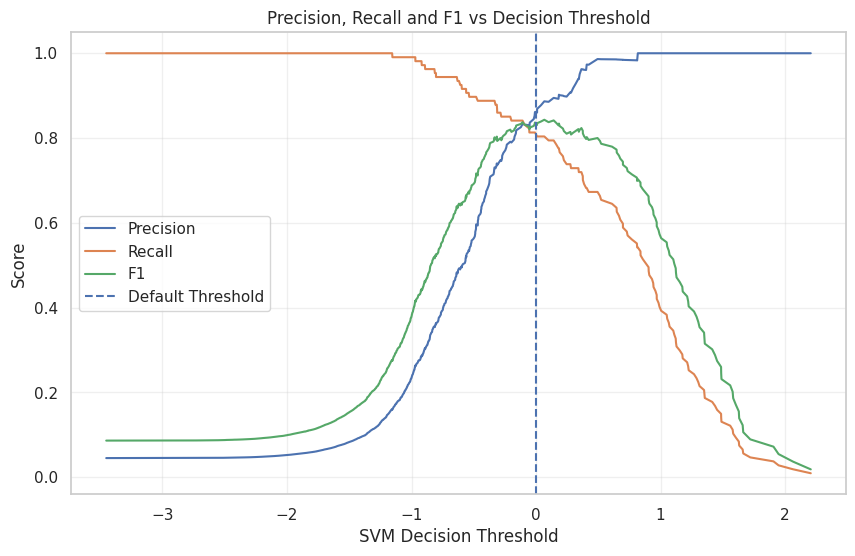

In [138]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    label="F1"
)

plt.axvline(
    0,
    linestyle="--",
    label="Default Threshold"
)

plt.xlabel("SVM Decision Threshold")
plt.ylabel("Score")

plt.title(
    "Precision, Recall and F1 vs Decision Threshold"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Locking the Threshold

In [139]:
FINAL_THRESHOLD = 0.0663

In [140]:
FINAL_THRESHOLD = float(
    best_f1_row["threshold"]
)

print("Selected threshold:", FINAL_THRESHOLD)

Selected threshold: 0.06632695148257528


In [141]:
y_val_final_pred = (
    val_scores >= FINAL_THRESHOLD
).astype(int)

In [142]:
print(
    confusion_matrix(
        y_val,
        y_val_final_pred
    )
)

print(
    classification_report(
        y_val,
        y_val_final_pred,
        digits=4
    )
)

[[2253   11]
 [  21   86]]
              precision    recall  f1-score   support

           0     0.9908    0.9951    0.9929      2264
           1     0.8866    0.8037    0.8431       107

    accuracy                         0.9865      2371
   macro avg     0.9387    0.8994    0.9180      2371
weighted avg     0.9861    0.9865    0.9862      2371



<h2>Feature Importance and Explainability

In [143]:
preprocessor = best_hybrid_svm.named_steps["preprocessor"]
svm_model = best_hybrid_svm.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()

coefficients = svm_model.coef_.ravel()

print("Number of transformed features:",
      len(feature_names))

print("Number of SVM coefficients:",
      len(coefficients))

Number of transformed features: 30108
Number of SVM coefficients: 30108


In [144]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df.head()

,feature,coefficient
0,text__00,-0.287303
1,text__00 00,-0.325187
2,text__00 hour,0.051086
3,text__00 pm,-0.087458
4,text__000,0.710440


In [145]:
top_fraud_features = (
    coef_df
    .sort_values(
        "coefficient",
        ascending=False
    )
    .head(30)
)

top_fraud_features

,feature,coefficient
28238,text__using link,1.929177
15313,text__line requirements,1.641505
1760,text__apply using,1.587259
743,text__accion,1.583429
18089,text__office manager,1.560638
17170,text__money,1.529380
15325,text__link,1.475939
23186,text__sales executive,1.316465
24229,text__sigma,1.240965
2042,text__assistant,1.191652


In [146]:
top_legitimate_features = (
    coef_df
    .sort_values(
        "coefficient",
        ascending=True
    )
    .head(30)
)

top_legitimate_features

,feature,coefficient
9047,text__english,-1.171332
4456,text__client,-0.984660
10246,text__experienced,-0.968160
30068,categorical__function_Writing/Editing,-0.908109
399,text__50,-0.886292
4937,text__commission,-0.859962
9929,text__experience,-0.827583
9483,text__essential,-0.823954
12005,text__growing,-0.779762
12203,text__handling,-0.778566


In [147]:
text_coef_df = coef_df[
    coef_df["feature"].str.startswith("text__")
].copy()

structured_coef_df = coef_df[
    ~coef_df["feature"].str.startswith("text__")
].copy()

print(
    "Text features:",
    len(text_coef_df)
)

print(
    "Structured features:",
    len(structured_coef_df)
)

Text features: 30000
Structured features: 108


In [148]:
top_structured_fraud = (
    structured_coef_df
    .sort_values(
        "coefficient",
        ascending=False
    )
    .head(25)
)

top_structured_fraud

,feature,coefficient
30098,categorical__industry_Oil & Energy,0.673978
30070,categorical__industry_Accounting,0.588894
30071,categorical__industry_Airlines/Aviation,0.436208
30078,categorical__industry_Design,0.385309
30081,categorical__industry_Electrical/Electronic Ma...,0.301723
30051,categorical__function_Education,0.279249
30094,categorical__industry_Management Consulting,0.250111
30064,categorical__function_Project Management,0.245978
30086,categorical__industry_Hospital & Health Care,0.244890
30047,categorical__function_Consulting,0.238187


In [149]:
top_structured_legitimate = (
    structured_coef_df
    .sort_values(
        "coefficient",
        ascending=True
    )
    .head(25)
)

top_structured_legitimate

,feature,coefficient
30068,categorical__function_Writing/Editing,-0.908109
30080,categorical__industry_Education Management,-0.577065
30063,categorical__function_Production,-0.492941
30076,categorical__industry_Construction,-0.492532
30091,categorical__industry_Internet,-0.481002
30084,categorical__industry_Food & Beverages,-0.479101
30054,categorical__function_Health Care Provider,-0.391854
30097,categorical__industry_Nonprofit Organization M...,-0.337966
30066,categorical__function_Quality Assurance,-0.320872
30032,categorical__required_education_Bachelor's Degree,-0.296032


<h3>Evaluate on Test-Set

In [150]:
# Final untouched test scores

test_scores = best_hybrid_svm.decision_function(
    test_fe
)

print("Number of test samples:", len(test_scores))
print(
    "Decision score range:",
    round(test_scores.min(), 4),
    "to",
    round(test_scores.max(), 4)
)

print("Locked threshold:", FINAL_THRESHOLD)

Number of test samples: 2372
Decision score range: -3.3379 to 1.6285
Locked threshold: 0.06632695148257528


In [151]:
y_test_final_pred = (
    test_scores >= FINAL_THRESHOLD
).astype(int)

In [152]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

test_precision = precision_score(
    y_test,
    y_test_final_pred
)

test_recall = recall_score(
    y_test,
    y_test_final_pred
)

test_f1 = f1_score(
    y_test,
    y_test_final_pred
)

test_accuracy = accuracy_score(
    y_test,
    y_test_final_pred
)

test_roc_auc = roc_auc_score(
    y_test,
    test_scores
)

test_pr_auc = average_precision_score(
    y_test,
    test_scores
)

test_cm = confusion_matrix(
    y_test,
    y_test_final_pred
)

In [153]:
print("=" * 60)
print("FINAL UNTOUCHED TEST EVALUATION")
print("=" * 60)

print(f"Threshold : {FINAL_THRESHOLD:.6f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1 Score  : {test_f1:.4f}")
print(f"Accuracy  : {test_accuracy:.4f}")
print(f"ROC-AUC   : {test_roc_auc:.4f}")
print(f"PR-AUC    : {test_pr_auc:.4f}")

print("\nConfusion Matrix:")
print(test_cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_final_pred,
        digits=4
    )
)

FINAL UNTOUCHED TEST EVALUATION
Threshold : 0.066327
Precision : 0.9070
Recall    : 0.7290
F1 Score  : 0.8083
Accuracy  : 0.9844
ROC-AUC   : 0.9820
PR-AUC    : 0.8872

Confusion Matrix:
[[2257    8]
 [  29   78]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9873    0.9965    0.9919      2265
           1     0.9070    0.7290    0.8083       107

    accuracy                         0.9844      2372
   macro avg     0.9471    0.8627    0.9001      2372
weighted avg     0.9837    0.9844    0.9836      2372



In [154]:
final_test_results = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1 Score",
        "Accuracy",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Test Score": [
        test_precision,
        test_recall,
        test_f1,
        test_accuracy,
        test_roc_auc,
        test_pr_auc
    ]
})

final_test_results.round(4)

,Metric,Test Score
0,Precision,0.9070
1,Recall,0.7290
2,F1 Score,0.8083
3,Accuracy,0.9844
4,ROC-AUC,0.9820
5,PR-AUC,0.8872


Compare Validation v/s Test

In [155]:
validation_vs_test = pd.DataFrame({

    "Metric": [
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Validation": [
        0.8866,
        0.8037,
        0.8431,
        0.9893,
        0.9037
    ],

    "Test": [
        test_precision,
        test_recall,
        test_f1,
        test_roc_auc,
        test_pr_auc
    ]
})

validation_vs_test["Difference"] = (
    validation_vs_test["Test"]
    - validation_vs_test["Validation"]
)

validation_vs_test.round(4)

,Metric,Validation,Test,Difference
0,Precision,0.8866,0.9070,0.0204
1,Recall,0.8037,0.7290,-0.0747
2,F1,0.8431,0.8083,-0.0348
3,ROC-AUC,0.9893,0.9820,-0.0073
4,PR-AUC,0.9037,0.8872,-0.0165


<h2>Final Model Packaging

In [156]:
import os
import json
import joblib
import sklearn
import pandas as pd
import numpy as np
import scipy

ARTIFACT_DIR = "/content/naukrishield_artifacts"

os.makedirs(
    ARTIFACT_DIR,
    exist_ok=True
)

print("Artifact directory created:")
print(ARTIFACT_DIR)

Artifact directory created:
/content/naukrishield_artifacts


In [157]:
MODEL_PATH = os.path.join(
    ARTIFACT_DIR,
    "naukrishield_hybrid_svm.joblib"
)

joblib.dump(
    best_hybrid_svm,
    MODEL_PATH
)

print("Model saved to:")
print(MODEL_PATH)

Model saved to:
/content/naukrishield_artifacts/naukrishield_hybrid_svm.joblib


In [158]:
raw_input_columns = [
    col
    for col in train_df.columns
    if col != "fraudulent"
]

metadata = {

    "project": "NaukriShield",

    "model_name":
        "Hybrid TF-IDF + Structured Linear SVM",

    "target":
        "fraudulent",

    "positive_class":
        1,

    "negative_class":
        0,

    "decision_threshold":
        float(FINAL_THRESHOLD),

    "raw_input_columns":
        raw_input_columns,

    "test_metrics": {
        "precision": float(test_precision),
        "recall": float(test_recall),
        "f1": float(test_f1),
        "accuracy": float(test_accuracy),
        "roc_auc": float(test_roc_auc),
        "pr_auc": float(test_pr_auc)
    },

    "library_versions": {
        "scikit_learn": sklearn.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scipy": scipy.__version__
    }
}

In [159]:
METADATA_PATH = os.path.join(
    ARTIFACT_DIR,
    "model_metadata.json"
)

with open(
    METADATA_PATH,
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )

print("Metadata saved to:")
print(METADATA_PATH)

Metadata saved to:
/content/naukrishield_artifacts/model_metadata.json


In [160]:
metadata

{'project': 'NaukriShield',
 'model_name': 'Hybrid TF-IDF + Structured Linear SVM',
 'target': 'fraudulent',
 'positive_class': 1,
 'negative_class': 0,
 'decision_threshold': 0.06632695148257528,
 'raw_input_columns': ['title',
  'location',
  'department',
  'salary_range',
  'company_profile',
  'description',
  'requirements',
  'benefits',
  'telecommuting',
  'has_company_logo',
  'has_questions',
  'employment_type',
  'required_experience',
  'required_education',
  'industry',
  'function',
  'title_clean',
  'company_profile_clean',
  'description_clean',
  'requirements_clean',
  'benefits_clean',
  'text'],
 'test_metrics': {'precision': 0.9069767441860465,
  'recall': 0.7289719626168224,
  'f1': 0.8082901554404145,
  'accuracy': 0.9844013490725126,
  'roc_auc': 0.9820057353881703,
  'pr_auc': 0.8871851751524414},
 'library_versions': {'scikit_learn': '1.6.1',
  'pandas': '2.2.3',
  'numpy': '2.1.3',
  'scipy': '1.16.3'}}

In [161]:
loaded_model = joblib.load(
    MODEL_PATH
)

with open(
    METADATA_PATH,
    "r"
) as f:

    loaded_metadata = json.load(f)

In [162]:
reloaded_test_scores = (
    loaded_model.decision_function(
        test_fe
    )
)

print(
    "Scores identical:",
    np.allclose(
        test_scores,
        reloaded_test_scores
    )
)

Scores identical: True


In [163]:
reloaded_threshold = (
    loaded_metadata[
        "decision_threshold"
    ]
)

print(
    "Threshold identical:",
    np.isclose(
        FINAL_THRESHOLD,
        reloaded_threshold
    )
)

Threshold identical: True


In [164]:
reloaded_predictions = (
    reloaded_test_scores
    >= reloaded_threshold
).astype(int)

print(
    "Predictions identical:",
    np.array_equal(
        y_test_final_pred,
        reloaded_predictions
    )
)

Predictions identical: True


# Final Production Packaging

In [167]:
%%writefile /content/naukrishield_artifacts/feature_engineering.py

import pandas as pd
import numpy as np

# PASTE THE EXACT add_engineered_features()
# FUNCTION FROM YOUR EARLIER NOTEBOOK CELL HERE.

def add_engineered_features(df):
    df = df.copy()

    # Text-length features

    text_cols = [
        "title",
        "company_profile",
        "description",
        "requirements",
        "benefits"
    ]

    for col in text_cols:
        df[f"{col}_word_count"] = (
            df[col]
            .fillna("")
            .astype(str)
            .str.split()
            .str.len()
        )

    # Combined text word count
    df["total_word_count"] = (
        df["text"]
        .fillna("")
        .astype(str)
        .str.split()
        .str.len()
    )

    # Missingness indicators

    missing_cols = [
        "company_profile",
        "salary_range",
        "department",
        "required_education",
        "benefits",
        "required_experience",
        "function",
        "industry",
        "employment_type",
        "requirements",
        "location"
    ]

    for col in missing_cols:
        df[f"{col}_missing"] = (
            df[col].isna().astype(int)
        )

    return df

Writing /content/naukrishield_artifacts/feature_engineering.py


In [168]:
import sys

sys.path.append(
    "/content/naukrishield_artifacts"
)

from feature_engineering import (
    add_engineered_features
)

print("Feature engineering module imported successfully.")

Feature engineering module imported successfully.


In [169]:
sample_raw = test_df.iloc[[0]].copy()

sample_fe = add_engineered_features(
    sample_raw
)

print("Raw shape:", sample_raw.shape)
print(
    "Engineered shape:",
    sample_fe.shape
)

Raw shape: (1, 23)
Engineered shape: (1, 40)


In [196]:
%%writefile /content/naukrishield_artifacts/inference.py

import os
import json
import joblib
import pandas as pd
import numpy as np

from feature_engineering import (
    add_engineered_features
)


import numpy as np
import pandas as pd


def normalize_api_input(job_data: dict) -> dict:
    """
    Convert JSON-compatible missing values (None)
    back to np.nan so inference matches training.
    """
    return {
        key: np.nan if value is None else value
        for key, value in job_data.items()
    }

BASE_DIR = os.path.dirname(
    os.path.abspath(__file__)
)

MODEL_PATH = os.path.join(
    BASE_DIR,
    "naukrishield_hybrid_svm.joblib"
)

METADATA_PATH = os.path.join(
    BASE_DIR,
    "model_metadata.json"
)


model = joblib.load(
    MODEL_PATH
)

with open(
    METADATA_PATH,
    "r"
) as f:
    metadata = json.load(f)


THRESHOLD = float(
    metadata["decision_threshold"]
)


def predict_job(job_data):
    """
    job_data:
        Python dictionary containing
        one raw job posting.

    Returns:
        prediction,
        label,
        decision score,
        threshold
    """

    job_data = normalize_api_input(job_data)

    raw_df = pd.DataFrame(
        [job_data]
    )

    engineered_df = (
        add_engineered_features(
            raw_df
        )
    )

    decision_score = float(
        model.decision_function(
            engineered_df
        )[0]
    )

    prediction = int(
        decision_score >= THRESHOLD
    )

    label = (
        "Fraudulent"
        if prediction == 1
        else "Legitimate"
    )

    return {
        "prediction": prediction,
        "label": label,
        "decision_score": decision_score,
        "threshold": THRESHOLD
    }

Overwriting /content/naukrishield_artifacts/inference.py


In [186]:
from inference import predict_job
sample_job = (
    test_df
    .drop(
        columns=["fraudulent"]
    )
    .iloc[0]
    .to_dict()
)

result = predict_job(
    sample_job
)

result

{'prediction': 0,
 'label': 'Legitimate',
 'decision_score': -1.4971058015003602,
 'threshold': 0.06632695148257528}

In [187]:
print(
    "Original notebook score:",
    test_scores[0]
)

print(
    "Inference module score:",
    result["decision_score"]
)

print(
    "Scores identical:",
    np.isclose(
        test_scores[0],
        result["decision_score"]
    )
)

Original notebook score: -1.4971058015003602
Inference module score: -1.4971058015003602
Scores identical: True


# Create the FASTAPI service

In [188]:
!pip install -q fastapi uvicorn

In [198]:
%%writefile /content/naukrishield_artifacts/app.py

from typing import Any

from fastapi import FastAPI, HTTPException

from inference import predict_job


app = FastAPI(
    title="NaukriShield ML API",
    description="Fake Job Posting Detection API",
    version="1.0.0"
)


@app.get("/")
def root():
    return {
        "message": "NaukriShield ML API is running"
    }


@app.get("/health")
def health():
    return {
        "status": "healthy",
        "model": "Hybrid Linear SVM"
    }


@app.post("/predict")
def predict_job_posting(
    job_data: dict[str, Any]
):
    try:

        result = predict_job(
            job_data
        )

        return result

    except Exception as e:

        raise HTTPException(
            status_code=400,
            detail=str(e)
        )

Overwriting /content/naukrishield_artifacts/app.py


In [199]:
import sys

sys.path.insert(
    0,
    "/content/naukrishield_artifacts"
)

from fastapi.testclient import TestClient
from app import app

client = TestClient(app)

In [200]:
response = client.get(
    "/health"
)

print(
    response.status_code
)

print(
    response.json()
)

200
{'status': 'healthy', 'model': 'Hybrid Linear SVM'}


In [201]:
import pandas as pd
import numpy as np

sample_job_raw = (
    test_df
    .drop(columns=["fraudulent"])
    .iloc[0]
    .to_dict()
)

sample_job = {
    key: (
        None
        if pd.isna(value)
        else value.item()
        if isinstance(value, np.generic)
        else value
    )
    for key, value in sample_job_raw.items()
}

sample_job

{'title': 'Manufacturing Engineer',
 'location': 'US, MI, Detroit',
 'department': None,
 'salary_range': None,
 'company_profile': '<p>We Provide Full Time Permanent Positions for many medium to large US companies. We are interested in finding/recruiting high quality candidates in IT, Engineering, Manufacturing and other highly technical and non-technical jobs.</p>',
 'description': '<p><b><i>(We have more than 1500+ Job openings in our website and some of them are relevant to this job. Feel free to search it in the website and apply directly. Just Click the “Apply Now” and you will redirect to our main website where you can search for the other jobs.)</i></b></p>\r\n<p></p>\r\n<p></p>\r\n<p></p>\r\n<p><b>Manufacturing Engineer :</b></p>\r\n<ul>\r\n<li>To support production to ensure that Customer demands are fully met</li>\r\n<li>To recommend and implement solutions to the day-to-day operational, quality and performance problems</li>\r\n<li>To recommend, plan, design and implement me

In [202]:
for key, value in sample_job.items():
    if value is None:
        print(key, "-> MISSING")

department -> MISSING
salary_range -> MISSING
requirements -> MISSING
benefits -> MISSING
required_experience -> MISSING
required_education -> MISSING
industry -> MISSING
function -> MISSING


In [203]:
response = client.post(
    "/predict",
    json=sample_job
)

print("Status:", response.status_code)
print(response.json())

Status: 200
{'prediction': 0, 'label': 'Legitimate', 'decision_score': -0.9301462776116816, 'threshold': 0.06632695148257528}


In [204]:
api_result = response.json()

print(
    "Original notebook score:",
    test_scores[0]
)

print(
    "FastAPI score:",
    api_result["decision_score"]
)

print(
    "Scores identical:",
    np.isclose(
        test_scores[0],
        api_result["decision_score"]
    )
)

print(
    "Notebook prediction:",
    y_test_final_pred[0]
)

print(
    "FastAPI prediction:",
    api_result["prediction"]
)

print(
    "Predictions identical:",
    int(y_test_final_pred[0])
    == int(api_result["prediction"])
)

Original notebook score: -1.4971058015003602
FastAPI score: -0.9301462776116816
Scores identical: False
Notebook prediction: 0
FastAPI prediction: 0
Predictions identical: True


In [197]:
import sys
import importlib
import numpy as np

ARTIFACT_DIR = "/content/naukrishield_artifacts"

if ARTIFACT_DIR not in sys.path:
    sys.path.insert(0, ARTIFACT_DIR)

import inference
importlib.reload(inference)

print("Inference module reloaded")

Inference module reloaded


In [205]:
raw_sample = (
    test_df
    .drop(columns=["fraudulent"], errors="ignore")
    .iloc[[0]]
    .copy()
)

recreated_sample = (
    inference.add_engineered_features(
        raw_sample
    )
    .reset_index(drop=True)
)

original_sample = (
    test_fe
    .drop(columns=["fraudulent"], errors="ignore")
    .iloc[[0]]
    .reset_index(drop=True)
)

print(
    "Original engineered shape:",
    original_sample.shape
)

print(
    "Recreated engineered shape:",
    recreated_sample.shape
)

print(
    "Same columns:",
    list(original_sample.columns)
    ==
    list(recreated_sample.columns)
)

Original engineered shape: (1, 39)
Recreated engineered shape: (1, 39)
Same columns: True


In [206]:
common_cols = [
    col
    for col in original_sample.columns
    if col in recreated_sample.columns
]

differences = []

for col in common_cols:

    a = original_sample.loc[0, col]
    b = recreated_sample.loc[0, col]

    if pd.isna(a) and pd.isna(b):
        continue

    if a != b:
        differences.append(
            {
                "column": col,
                "original": a,
                "recreated": b
            }
        )

difference_df = pd.DataFrame(differences)

print(
    "Number of differing columns:",
    len(difference_df)
)

difference_df

Number of differing columns: 0


""
